# Проектная работа по теме: "Анализ бизнес-показателей"

**Описание проекта**\
Я — маркетинговый аналитик развлекательного приложения Procrastinate Pro+. Несмотря на огромные вложения в рекламу, последние несколько месяцев компания терпит убытки. 

**Цель исследования:**\
проанализировать данные, разобраться по какой причине компания терпит убытки и помочь ей выйти в плюс.


 **Описание данных:**\
Есть данные о пользователях, привлечённых с 1 мая по 27 октября 2019 года:
1) лог сервера с данными об их посещениях;\
2) выгрузка их покупок за этот период;\
3) рекламные расходы.

**Необходимо изучить**:
1) откуда приходят пользователи и какими устройствами они пользуются;\
2) сколько стоит привлечение пользователей из различных рекламных каналов;\
3) сколько денег приносит каждый клиент;\
4) когда расходы на привлечение клиента окупаются;\
5) какие факторы мешают привлечению клиентов.

**План исследования:**
1) изучить общую информацию, выполнить предобработку данных;\
2) задать функции для расчёта и анализа LTV, ROI, удержания и конверсии;\
3) провести исследовательский анализ (составить профили пользователей; выяснить, из каких стран приходят пользователи и какими устройствами пользуются; изучить рекламные источники привлечения);\
4) исследовать маркетинг компании;\
5) оценить окупаемость рекламы;\
6) общий вывод.

### Загрузите данные и подготовьте их к анализу

In [1]:
import pandas as pd 
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### Загрузка данных

In [2]:
# сохраняем датафрейм с информацией о визитах
try:
    visits = pd.read_csv('/datasets/visits_info_short.csv')
except:
    visits = pd.read_csv('https://code.s3.yandex.net/datasets/visits_info_short.csv')

# сохраняем датафрейм с информацией о заказах
try:
    orders = pd.read_csv('/datasets/orders_info_short.csv')
except:
    orders = pd.read_csv('https://code.s3.yandex.net/datasets/orders_info_short.csv')

# сохраняем датафрейм с информацией о расходах   
try:
    costs = pd.read_csv('/datasets/costs_info_short.csv')
except:
    costs = pd.read_csv('https://code.s3.yandex.net/datasets/costs_info_short.csv')


#### Общая информация

In [3]:
# смотрим основную информацию датафрейма visits
display(visits.head())
print()
visits.info()

,User Id,Region,Device,Channel,Session Start,Session End
0,981449118918,United States,iPhone,organic,2019-05-01 02:36:01,2019-05-01 02:45:01
1,278965908054,United States,iPhone,organic,2019-05-01 04:46:31,2019-05-01 04:47:35
2,590706206550,United States,Mac,organic,2019-05-01 14:09:25,2019-05-01 15:32:08
3,326433527971,United States,Android,TipTop,2019-05-01 00:29:59,2019-05-01 00:54:25
4,349773784594,United States,Mac,organic,2019-05-01 03:33:35,2019-05-01 03:57:40



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   User Id        309901 non-null  int64 
 1   Region         309901 non-null  object
 2   Device         309901 non-null  object
 3   Channel        309901 non-null  object
 4   Session Start  309901 non-null  object
 5   Session End    309901 non-null  object
dtypes: int64(1), object(5)
memory usage: 14.2+ MB


Тип данных столбцов Session Start и Session End не соответствует правильному - datetime.\
К тому же нужно переименовать столбцы, используя стиль snake case. 

In [4]:
# переименовываем столбцы в датафрейме visits
visits.columns = [x.lower().replace(' ', '_') for x in visits.columns.values]

# меняем тип данных в столбцах session_start и session_end на datetime
visits['session_start'] = pd.to_datetime(visits['session_start'])
visits['session_end'] = pd.to_datetime(visits['session_end'])


# проверяем
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        309901 non-null  int64         
 1   region         309901 non-null  object        
 2   device         309901 non-null  object        
 3   channel        309901 non-null  object        
 4   session_start  309901 non-null  datetime64[ns]
 5   session_end    309901 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 14.2+ MB


In [5]:
# смотрим основную информацию датафрейма orders
display(orders.head())
print()
orders.info()

,User Id,Event Dt,Revenue
0,188246423999,2019-05-01 23:09:52,4.99
1,174361394180,2019-05-01 12:24:04,4.99
2,529610067795,2019-05-01 11:34:04,4.99
3,319939546352,2019-05-01 15:34:40,4.99
4,366000285810,2019-05-01 13:59:51,4.99



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User Id   40212 non-null  int64  
 1   Event Dt  40212 non-null  object 
 2   Revenue   40212 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 942.6+ KB


Необходимо:
1) переименовать столбцы;\
2) изменить тип данных столбца Event Dt на datetime.

In [6]:
# переименовываем столбцы в датафрейме orders
orders.columns = [x.lower().replace(' ', '_') for x in orders.columns.values]

# меняем тип данных в столбце event_dt на datetime
orders['event_dt'] = pd.to_datetime(orders['event_dt'])

# проверяем
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   40212 non-null  int64         
 1   event_dt  40212 non-null  datetime64[ns]
 2   revenue   40212 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 942.6 KB


In [7]:
# смотрим основную информацию датафрейма costs
display(costs.head())
print()
costs.info()

,dt,Channel,costs
0,2019-05-01,FaceBoom,113.3
1,2019-05-02,FaceBoom,78.1
2,2019-05-03,FaceBoom,85.8
3,2019-05-04,FaceBoom,136.4
4,2019-05-05,FaceBoom,122.1



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       1800 non-null   object 
 1   Channel  1800 non-null   object 
 2   costs    1800 non-null   float64
dtypes: float64(1), object(2)
memory usage: 42.3+ KB


Необходимо:
1) переименовать столбец Channel;\
2) изменить тип данных столбца dt на datetime.

In [8]:
# переименовываем столбцы в датафрейме costs
costs.columns = [x.lower().replace(' ', '_') for x in costs.columns.values]

# меняем тип данных в столбце dt на datetime
costs['dt'] = pd.to_datetime(costs['dt']).dt.date


# проверяем
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       1800 non-null   object 
 1   channel  1800 non-null   object 
 2   costs    1800 non-null   float64
dtypes: float64(1), object(2)
memory usage: 42.3+ KB


#### Обработка пропусков

In [9]:
# выводим количество пропущенных значений для каждого столбца датафрейма visits
print(visits.isna().sum())
print()

# выводим количество пропущенных значений для каждого столбца датафрейма orders
print(orders.isna().sum())
print()

# выводим количество пропущенных значений для каждого столбца датафрейма costs
print(costs.isna().sum())

user_id          0
region           0
device           0
channel          0
session_start    0
session_end      0
dtype: int64

user_id     0
event_dt    0
revenue     0
dtype: int64

dt         0
channel    0
costs      0
dtype: int64


Пропусков в датафреймах нет.

#### Обработка дубликатов

In [10]:
# проверяем на наличие явных дубликатов датафрейм visits
print(visits.duplicated().sum())
print()

# проверяем на наличие явных дубликатов датафрейм orders
print(orders.duplicated().sum())
print()

# проверяем на наличие явных дубликатов датафрейм costs
print(costs.duplicated().sum())
print()


0

0

0



Явных дубликатов нет.

Проверяем на наличие неявных дубликатов:

In [11]:
в

# проверяем на наличие неявных дубликатов датафрейм visits столбец device
print(visits['device'].unique())
print()

# проверяем на наличие неявных дубликатов датафрейм visits столбец channel
print(visits['channel'].unique())
print()

# проверяем на наличие неявных дубликатов датафрейм costs столбец сhannel
print(costs['channel'].unique())


['United States' 'UK' 'France' 'Germany']

['iPhone' 'Mac' 'Android' 'PC']

['organic' 'TipTop' 'RocketSuperAds' 'YRabbit' 'FaceBoom' 'MediaTornado'
 'AdNonSense' 'LeapBob' 'WahooNetBanner' 'OppleCreativeMedia'
 'lambdaMediaAds']

['FaceBoom' 'MediaTornado' 'RocketSuperAds' 'TipTop' 'YRabbit'
 'AdNonSense' 'LeapBob' 'OppleCreativeMedia' 'WahooNetBanner'
 'lambdaMediaAds']


Неявные дубликаты не были обнаружены.

#### Вывод

На этапе предобработки было сделано следующее:
1) изменение названий столбцов в соответствии с общепринятым стилем;\
2) изменение типа данных object на datetime в столбцах с датой и временем;\
3) проверка на пропуски, явные и неявные дубликаты - таковых обнаружено не было.

### Задайте функции для расчёта и анализа LTV, ROI, удержания и конверсии.

#### Функция для создания профилей пользователей

In [12]:
# задаем функцию для создания профилей пользователей get_profiles()

def get_profiles(sessions, orders, ad_costs):
    # передадим в функцию расчета профиля данные о рекламных затратах (фрейм ad_costs)
 
    # сортируем сессии по id пользователя и дате для того,чтобы работал first
    # находим первые значения для параметров пользователя - будем считать их основными 
    profiles = (
        sessions.sort_values(by = ['user_id', 'session_start'])           
        .groupby('user_id')
        .agg(
            {
                'session_start' : 'first',       
                'channel': 'first',
                'device': 'first',
                'region': 'first'
            }
        )                                 
        .rename(columns = {'session_start' : 'first_ts'})  
        .reset_index()  # вернем все данные из индекса в колонки                                           
     )
    
    # определим дату первого посещения 
    # и начало месяца первого посещения - они понадобятся нам при когортном анализе
    profiles['dt'] = profiles['first_ts'].dt.date                                 
    profiles['month'] = profiles['first_ts'].astype('datetime64[M]')     
 
    # добавляем признак платящих пользователей
    profiles['payer'] = profiles['user_id'].isin(orders['user_id'].unique())   
  
    # к данным о рекламных затратах добавим количества привлеченных пользователей
    # с одинаковыми источником и датой привлечения
    new_users = (
        profiles.groupby(['dt', 'channel'])
        .agg({'user_id': 'nunique'})
        .rename(columns={'user_id': 'unique_users'})
        .reset_index()
    )
    
    # объединяем траты на рекламу и число привлечённых пользователей
    ad_costs = ad_costs.merge(new_users, on = ['dt', 'channel'], how = 'left')
    
    # найдем среднюю стоимость привлечения пользователя
    ad_costs['acquisition_cost'] = ad_costs['costs'] / ad_costs['unique_users']
 
     # добавляем стоимость привлечения в профили
    profiles = profiles.merge(
        ad_costs[['dt', 'channel', 'acquisition_cost']],
        on=['dt', 'channel'],
        how='left',
    )

    # стоимость привлечения органических пользователей равна нулю
    profiles['acquisition_cost'] = profiles['acquisition_cost'].fillna(0)
 
    return profiles # возвращаем профили с CAC

#### Функция для подсчёта Retention Rate

In [13]:
# задаем функцию для подсчёта Retention Rate (для расчета удержания) get_retention()
def get_retention(
    profiles,
    sessions,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):
    # добавляем столбец payer в передаваемый dimensions список
    dimensions = ['payer'] + dimensions
 
    # оттсекаем всех пользователей, которые не могли "дожить" до нужного горизонта 
    # (присоединились позже чем observation_date - horizon)
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days = horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')
    
    # формируем массив сырых данных
    result_raw = result_raw.merge(
        sessions[['user_id', 'session_start']], on = 'user_id', how = 'left'
    )
    result_raw['lifetime'] = (
        result_raw['session_start'] - result_raw['first_ts']
    ).dt.days
 
    # функция группировки по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):     
        result = df.pivot_table(
            index = dims, columns = 'lifetime', values = 'user_id', aggfunc = 'nunique'
        )     
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns = {'user_id': 'cohort_size'})
        ) 
        # присоединяем размеры когорт к треугольной таблице
        result = cohort_sizes.merge(result, on = dims, how = 'left').fillna(0) 
        # делим каждый из столбцов на размер когорты - расчитываем % удержания (retention rate)
        result = result.div(result['cohort_size'], axis = 0)  
        # оставляем только наблюдения до нужного горизонта и столбец размеров когорт
        result = result[['cohort_size'] + list(range(horizon_days))]     
        # пересприсваиваем столбец размеров когорт, ведь во время деления он превратился в 1
        result['cohort_size'] = cohort_sizes                                   
        return result

    # расчитываем удержание 
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)
 
    # рассчитываем удержание по всем параметрам + дата
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )
 
    # возвращаем таблицы удержания и сырые данные 
    return result_raw, result_grouped, result_in_time

#### Функция для подсчёта конверсии

In [14]:
# задаем функцию для подсчёта конверсии get_conversion()
def get_conversion(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # оттсекаем всех пользователей, которые не могли "дожить" до нужного горизонта 
    # (присоединились позже чем observation_date - horizon)
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # определяем дату и время первой покупки для каждого пользователя
    first_purchases = (
        purchases.sort_values(by=['user_id', 'event_dt'])
        .groupby('user_id')
        .agg({'event_dt': 'first'})
        .reset_index()
    )
   
    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        first_purchases[['user_id', 'event_dt']], on='user_id', how='left'
    )

    # рассчитываем лайфтайм для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days

    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users' 
        dimensions = dimensions + ['cohort']
        
    # функция группировки по нужному набору измерений
    def group_by_dimensions(df, dims, horizon_days):   
        result = df.pivot_table(
            index = dims, columns = 'lifetime', values = 'user_id', aggfunc = 'nunique'
        )     # строим "треугольную таблицу"         
 
        # просуммируем ячейки таблицы конверсии вдоль каждого ряда с накоплением
        result = result.fillna(0).cumsum(axis = 1) 
        
        # расчитываем размеры когорт и соединяем таблицы размеров когорт и таблицу конверсии
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns = {'user_id': 'cohort_size'})
        ) # определяем размеры когорт
        result = cohort_sizes.merge(result, on = dims, how = 'left').fillna(0) # присоединяем размеры когорт к треугольной таблице
 
        # разделим каждую ячейку таблицы конверсии на соответствующий размер когорты
        # делим каждый из столбцов на размер когорты 
        result = result.div(result['cohort_size'], axis = 0)
        # оставляем только наблюдения до нужного горизонта и столбец размеров когорт
        result = result[['cohort_size'] + list(range(horizon_days))] 
        # пересприсваиваем столбец размеров когорт, ведь во время деления он превратился в 1
        result['cohort_size'] = cohort_sizes                         
        return result
       
    # получаем таблицу конверсии
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # рассчитываем конверсию по всем параметрам + дата
    if 'cohort' in dimensions: 
        dimensions = [] 

    # получаем таблицу динамики конверсии
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем таблицы конверсии и сырые данные 
    return result_raw, result_grouped, result_in_time 

#### Функция для подсчёта LTV и ROI

In [15]:
# задаем функцию для подсчёта LTV и ROI get_ltv()
def get_ltv(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):
    
    # оттсекаем всех пользователей, которые не могли "дожить" до нужного горизонта 
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')
 
    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        purchases[['user_id', 'event_dt', 'revenue']], on='user_id', how='left'
    )
    # рассчитываем лайфтайм пользователя для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days
    
    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']  
 
    # функция группировки по нужному набору измерений
    def group_by_dimensions(df, dims, horizon_days):  
        # построим сводную таблицу, у которой в строках находятся даты первой посещения пользователей, 
        # в столбцах - lifetime, а в ячейках сумма покупок пользователей на заданный лайфтайм. 
        # таким образом, мы получим таблицу выручки
        result = df.pivot_table(
            index=dims, columns='lifetime', values='revenue', aggfunc='sum'
        )         # строим "треугольную таблицу"         
 
        # просуммируем ячейки таблицы конверсии вдоль каждого ряда с накоплением
        result = result.fillna(0).cumsum(axis = 1)
 
        # расчитаем размеры когорт 
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns = {'user_id': 'cohort_size'})
        ) 
        # объединяем размеры когорт и таблицу выручки
        result = cohort_sizes.merge(result, on = dims, how = 'left').fillna(0) 
 
        # считаем LTV: делим каждую «ячейку» в строке на размер когорты
        result = result.div(result['cohort_size'], axis = 0) 
        # оставляем только наблюдения до нужного горизонта и столбец размеров когорт
        result = result[['cohort_size'] + list(range(horizon_days))] 
        # пересприсваиваем столбец размеров когорт, ведь во время деления он превратился в 1
        result['cohort_size'] = cohort_sizes                          
 
        # расчитаем CAC
        # в таблице df одному пользователю соответствует несколько строк, поэтому 
        # вернемся к уникальным пользователям с помощью drop_duplicates
        cac = df[['user_id', 'acquisition_cost'] + dims].drop_duplicates()
        # считаем средний CAC по параметрам из dimensions
        cac = (
            cac.groupby(dims)
            .agg({'acquisition_cost': 'mean'})
            .rename(columns={'acquisition_cost': 'cac'})
        )
 
        # считаем ROI: делим LTV на CAC
        roi = result.div(cac['cac'], axis=0)
 
        # удаляем строки с бесконечным ROI
        roi = roi[~roi['cohort_size'].isin([np.inf])]
 
        # восстанавливаем размеры когорт в таблице ROI
        roi['cohort_size'] = cohort_sizes

        # добавляем CAC в таблицу ROI
        roi['cac'] = cac['cac']

        # в финальной таблице оставляем размеры когорт, CAC
        # и ROI в лайфтаймы, не превышающие горизонт анализа
        roi = roi[['cohort_size', 'cac'] + list(range(horizon_days))]

        # возвращаем таблицы LTV и ROI
        return result, roi

    # получаем таблицы LTV и ROI
    result_grouped, roi_grouped = group_by_dimensions(
        result_raw, dimensions, horizon_days
    )

    # для таблиц динамики убираем 'cohort' из dimensions
    if 'cohort' in dimensions:
        dimensions = []

    # получаем таблицы динамики LTV и ROI
    result_in_time, roi_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )
    
    # возвращаем и таблицы LTV, ROI и сырые данные
    return (
        result_raw,  # сырые данные
        result_grouped,  # таблица LTV
        result_in_time,  # таблица динамики LTV
        roi_grouped,  # таблица ROI
        roi_in_time,  # таблица динамики ROI
    ) 

#### Функция для сглаживания данных

In [16]:
# задаем функцию для сглаживания данных filter_data()
def filter_data(df, window):
    # для каждого столбца применяем скользящее среднее
    for column in df.columns.values:
        df[column] = df[column].rolling(window).mean() 
    return df 

#### Функция для построения графика Retention Rate

In [17]:
# задаем функцию для построения графика Retention Rate plot_retention()
def plot_retention(retention, retention_history, horizon, window = 7):
    # задаем сетку отрисовки графиков
    plt.subplots(figsize = (15, 10))
 
    # проверим размер индекса - если в нем только один столбец payer, 
    # то добавим еще один - иначе функция будет ломаться
    if retention.index.nlevels == 1:
        retention['cohort'] = 'All users' 
        retention = retention.reset_index().set_index(['cohort', 'payer']) 
 
    # исключаем размеры когорт и удержание первого дня
    retention = retention.drop(columns=['cohort_size', 0])
    # в таблице динамики оставляем только нужный лайфтайм
    retention_history = retention_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]
    
    # первый график - кривые удержания для платящих пользователей
    ax1 = plt.subplot(2, 2, 1)
    retention.query('payer == True').droplevel('payer').T.plot(
        grid = True, ax = ax1
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание платящих пользователей')  
 
    # второй график - кривые удержания для неплатящих пользователей
    # вертикальная ось — от графика из первой ячейки
    ax2 = plt.subplot(2, 2, 2, sharey = ax1)
    retention.query('payer == False').droplevel('payer').T.plot(
        grid = True, ax = ax2
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание неплатящих пользователей')

    # третий график - динамика изменения удержания для платящих пользователей
    ax3 = plt.subplot(2, 2, 3)
    # в колонки сводной таблицы для графиков попадут все колонки индекса, кроме даты и признака платящих пользователей
    columns = [
        name
        for name in retention_history.index.names
        if name not in ['dt', 'payer']
    ]
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == True').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика удержания платящих пользователей на {}-й день'.format(horizon))  

    # четвертый график - динамика изменения удержания для неплатящих пользователей    
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == False').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax4)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика удержания неплатящих пользователей на {}-й день'.format(horizon)) 
    
    # иногда графики могут накладываться друг на друга
    # чтобы этого избежать - используем tight_layout
    plt.tight_layout() 
    plt.show() 

#### Функция для построения графика конверсии

In [18]:
# задаем функцию для построения графика конверсии plot_conversion()
def plot_conversion(conversion, conversion_history, horizon, window=7):

    # задаем сетку отрисовки графиков
    plt.subplots(figsize = (15, 10))

    # исключаем размеры когорт
    conversion = conversion.drop(columns=['cohort_size'])
    # в таблице динамики оставляем только нужный лайфтайм
    conversion_history = conversion_history.drop(columns=['cohort_size'])[[horizon - 1]]

    # первый график — кривые конверсии
    ax1 = plt.subplot(2, 2, 1)
    conversion.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Конверсия пользователей')

    # второй график — динамика конверсии
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    # в колонки сводной таблицы для графиков попадут все колонки индекса, кроме даты 
    columns = [
        name for name in conversion_history.index.names if name not in ['dt']] 
    filtered_data = conversion_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика конверсии пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show() 

#### Функция для визуализации LTV и ROI

In [19]:
# задаем функцию для визуализации LTV и ROI plot_ltv_roi
def plot_ltv_roi(ltv, ltv_history, roi, roi_history, horizon, window = 7):
    # задаем сетку отрисовки графкиков
    plt.subplots(figsize = (20, 10))
 
    # из таблицы ltv исключаем размеры когорт
    ltv = ltv.drop(columns = ['cohort_size']) 
    # в таблице динамики ltv оставляем только нужный лайфтайм
    ltv_history = ltv_history.drop(columns = ['cohort_size'])[[horizon - 1]]
 
    # запишем стоимость привлечения CAC в отдельный фрейм
    cac_history = roi_history[['cac']]
    
    # из таблицы roi исключаем размеры когорт и cac
    roi = roi.drop(columns = ['cohort_size', 'cac']) 
    # в таблице динамики roi оставляем только нужный лайфтайм
    roi_history = roi_history.drop(columns = ['cohort_size', 'cac'])[[horizon - 1]]
    
    # первый график - кривые ltv
    ax1 = plt.subplot(2, 3, 1)
    ltv.T.plot(grid = True, ax = ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('LTV')  
    
    # второй график - динамика ltv
    ax2 = plt.subplot(2, 3, 2, sharey = ax1)
    # в колонки сводной таблицы для графиков попадут все колонки индекса, кроме даты 
    columns = [name for name in ltv_history.index.names if name not in ['dt']] 
    filtered_data = ltv_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid = True, ax = ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика LTV пользователей на {}-й день'.format(horizon))  
    
    # третий график - динамика cac
    ax3 = plt.subplot(2, 3, 3, sharey = ax1)
    # в колонки сводной таблицы для графиков попадут все колонки индекса, кроме даты 
    columns = [name for name in cac_history.index.names if name not in ['dt']] 
    filtered_data = cac_history.pivot_table(
        index='dt', columns=columns, values='cac', aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid = True, ax = ax3)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика стоимости привлечения пользователей')  
 
    # четвёртый график — кривые roi
    ax4 = plt.subplot(2, 3, 4)
    roi.T.plot(grid=True, ax=ax4)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('ROI')

    # пятый график — динамика roi
    ax5 = plt.subplot(2, 3, 5, sharey=ax4)
    # в колонки сводной таблицы для графиков попадут все колонки индекса, кроме даты
    columns = [name for name in roi_history.index.names if name not in ['dt']]
    filtered_data = roi_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax5)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.xlabel('Дата привлечения')
    plt.title('Динамика ROI пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show()

Мы задали функции для вычисления значений метрик:\
get_profiles() — для создания профилей пользователей,\
get_retention() — для подсчёта Retention Rate,\
get_conversion() — для подсчёта конверсии,\
get_ltv() — для подсчёта LTV.

А также функции для построения графиков:\
filter_data() — для сглаживания данных,\
plot_retention() — для построения графика Retention Rate,\
plot_conversion() — для построения графика конверсии,\
plot_ltv_roi — для визуализации LTV и ROI.

### Исследовательский анализ данных

- Составьте профили пользователей. Определите минимальную и максимальную даты привлечения пользователей.
- Выясните, из каких стран пользователи приходят в приложение и на какую страну приходится больше всего платящих пользователей. Постройте таблицу, отражающую количество пользователей и долю платящих из каждой страны.
- Узнайте, какими устройствами пользуются клиенты и какие устройства предпочитают платящие пользователи. Постройте таблицу, отражающую количество пользователей и долю платящих для каждого устройства.
- Изучите рекламные источники привлечения и определите каналы, из которых пришло больше всего платящих пользователей. Постройте таблицу, отражающую количество пользователей и долю платящих для каждого канала привлечения.

После каждого пункта сформулируйте выводы.

#### Профили пользователей, минимальная и максимальная даты привлечения

In [20]:
# составляем профили пользователей
profiles = get_profiles(visits, orders, costs)
display(profiles.head())
print()


# определяем минимальную и максимальную даты привлечения пользователей
min_acquitision_dt = profiles['dt'].min()
print(min_acquitision_dt)

max_acquitision_dt = profiles['dt'].max()
print(max_acquitision_dt)

,user_id,first_ts,channel,device,region,dt,month,payer,acquisition_cost
0,599326,2019-05-07 20:58:57,FaceBoom,Mac,United States,2019-05-07,2019-05-01,True,1.088172
1,4919697,2019-07-09 12:46:07,FaceBoom,iPhone,United States,2019-07-09,2019-07-01,False,1.107237
2,6085896,2019-10-01 09:58:33,organic,iPhone,France,2019-10-01,2019-10-01,False,0.000000
3,22593348,2019-08-22 21:35:48,AdNonSense,PC,Germany,2019-08-22,2019-08-01,False,0.988235
4,31989216,2019-10-02 00:07:44,YRabbit,iPhone,United States,2019-10-02,2019-10-01,False,0.230769



2019-05-01
2019-10-27


Мы получили таблицу профилей пользователей, а также определили минимальную и максимальную даты привлечения - 2019.05.01 и 2019.10.27 соответственно. \
Даты совпадают с датами, обозначенными в ТЗ.

#### Распределение платящих и всех пользователей по странам

In [21]:
# строим таблицу, отражающую общее количество пользователей, количество платящих
# пользователей и их долю по странам

# считаем количество пользователей и среднее платящих пользователей по странам,

regions = (
    profiles.groupby('region')
      .agg({'user_id' : 'nunique', 'payer' : 'mean'})
      .rename(columns = {'user_id' : 'users_count', 'payer' : 'mean_of_payers'})
  )
# считаем количество платящих пользователей 
regions['payers_count'] = profiles.query("payer == True").groupby('region').agg({'payer':'count'})
# переводим среднее платящих пользователей в процентную долю по странам
regions['perc_of_payers'] = (regions['mean_of_payers']*100).round(2)
# выполняем сортировку по убыванию в столбце с долей платящих пользователей
regions = regions.sort_values(by='perc_of_payers', ascending=False)
                              
display(regions)

,users_count,mean_of_payers,payers_count,perc_of_payers
region,,,,
United States,100002,0.069019,6902,6.90
Germany,14981,0.041119,616,4.11
UK,17575,0.039829,700,3.98
France,17450,0.037994,663,3.80


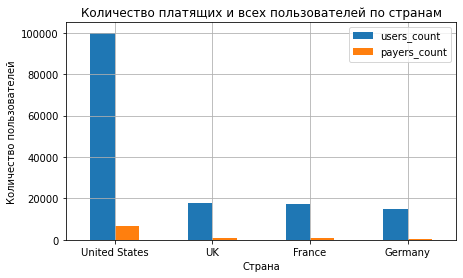

In [22]:
# выполняем сортировку по убыванию в столбце с количеством платящих пользователей
regions = regions.sort_values(by='payers_count', ascending=False)                          

# визуализируем разницу в количестве платящих и всех пользователей по странам
regions[['users_count', 'payers_count']].plot(kind='bar', grid=True, figsize=(7, 4))
plt.xlabel('Страна')
plt.ylabel('Количество пользователей')
plt.title('Количество платящих и всех пользователей по странам')
plt.xticks(rotation=0)
plt.show()

Пользователи приходят в приложение из США, Великобритании, Франции и Германии, больше всего - из США(100002 пользователей).Также именно на США приходятся наибольшие количество(6902) и доля(6.9%) платящих пользователей.\
Меньше всего пользователей приходят из Germany (14981), количество платящих - 616 пользователей, доля - 4.1%

####  Распределение платящих и всех пользователей по устройствам

In [23]:
# строим таблицу, отражающую общее количество пользователей, количество платящих
# пользователей и их долю по устройствам

# считаем количество пользователей и среднее платящих пользователей по устройствам,
devices = (
    profiles.groupby('device')
      .agg({'user_id' : 'nunique', 'payer' : 'mean'})
      .rename(columns = {'user_id' : 'users_count', 'payer' : 'mean_of_payers'})
  )
# считаем количество платящих пользователей
devices['payers_count'] = profiles.query("payer == True").groupby('device').agg({'payer':'count'})
# переводим среднее платящих пользователей в процентную долю 
devices['perc_of_payers'] = (devices['mean_of_payers']*100).round(2)
# выполняем сортировку по убыванию в столбце с долей платящих пользователей
devices = devices.sort_values(by='perc_of_payers', ascending=False)

display(devices)

,users_count,mean_of_payers,payers_count,perc_of_payers
device,,,,
Mac,30042,0.063644,1912,6.36
iPhone,54479,0.062079,3382,6.21
Android,35032,0.058518,2050,5.85
PC,30455,0.050468,1537,5.05


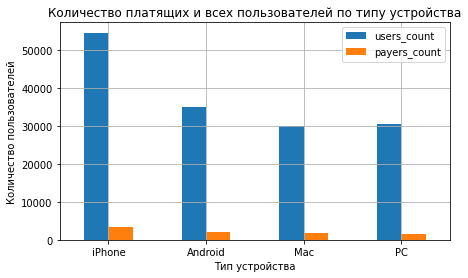

In [24]:
# выполняем сортировку по убыванию в столбце с количеством платящих пользователей
devices = devices.sort_values(by='payers_count', ascending=False)
                              
# визуализируем разницу в количестве платящих и всех пользователей по устройствам
devices[['users_count', 'payers_count']].plot(kind='bar', grid=True, figsize=(7, 4))
plt.xlabel('Тип устройства')
plt.ylabel('Количество пользователей')
plt.title('Количество платящих и всех пользователей по типу устройства')
plt.xticks(rotation=0)
plt.show()

Клиенты пользуются следующими устройствами: iPhone, Android, ПК, Mac, при этом наибольшее количество платящих(3382 пользователей) и всех пользователей(54479) используют iPhone. Но в долевом соотношении платящие пользователи предпочитают устройства iPhone(6.2%) и Mac (6.36%).\
Меньше всего пользователей приходят из устройств PC (30455), количество платящих - 1537 пользователей, доля - 5%

####  Распределение платящих и всех пользователей по каналам привлечения

In [25]:
# строим таблицу, отражающую общее количество пользователей, количество платящих
# пользователей и их долю по каналам привлечения

# считаем количество пользователей и среднее платящих пользователей по каналам привлечения,
channels = (
    profiles.groupby('channel')
      .agg({'user_id' : 'nunique', 'payer' : 'mean'})
      .rename(columns = {'user_id' : 'users_count', 'payer' : 'mean_of_payers'})
  )
# считаем количество платящих пользователей
channels['payers_count'] = profiles.query("payer == True").groupby('channel').agg({'payer':'count'})
# переводим среднее платящих пользователей в процентную долю 
channels['perc_of_payers'] = (channels['mean_of_payers']*100).round(2)
# выполняем сортировку по убыванию в столбце с долей платящих пользователей
channels = channels.sort_values(by='perc_of_payers', ascending=False)
display(channels)

,users_count,mean_of_payers,payers_count,perc_of_payers
channel,,,,
FaceBoom,29144,0.122049,3557,12.20
AdNonSense,3880,0.113402,440,11.34
lambdaMediaAds,2149,0.104700,225,10.47
TipTop,19561,0.096007,1878,9.60
RocketSuperAds,4448,0.079137,352,7.91
WahooNetBanner,8553,0.052964,453,5.30
YRabbit,4312,0.038265,165,3.83
MediaTornado,4364,0.035747,156,3.57
LeapBob,8553,0.030633,262,3.06


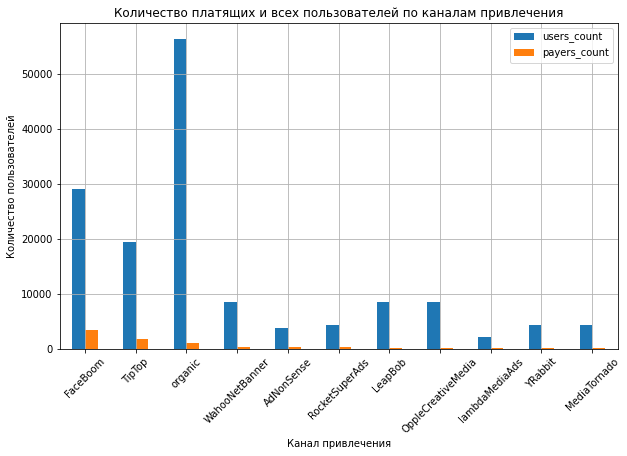

In [26]:
# выполняем сортировку по убыванию в столбце с количеством платящих пользователей
channels = channels.sort_values(by='payers_count', ascending=False)

# визуализируем разницу в количестве платящих и всех пользователей по каналам привлечения
channels[['users_count', 'payers_count']].plot(kind='bar', grid=True, figsize=(10, 6))
plt.xlabel('Канал привлечения')
plt.ylabel('Количество пользователей')
plt.title('Количество платящих и всех пользователей по каналам привлечения')
plt.xticks(rotation=45)
plt.show()

Больше всего платящих и всех пользователей пришло из каналов: FaceBoom (29144), TipTop(19561) и organic (органический трафик)(56439).\
При этом доля платящих пользователей выше у каналов: FaceBoom(12.2%), AdNonSense(11.3%), lambdaMediaAds (10.47%).\
Меньше всего пользователей приходят из источника MediaTornado (4364), количество платящих - 156 пользователей, доля - 3.5%.

####  Выводы по исследовательскому анализу

1. Минимальная и максимальная даты привлечения - 2019.05.01 и 2019.10.27 соответственно.


2. Пользователи приходят в приложение из США, Великобритании, Франции и Германии, больше всего - из США(100002 пользователей).Также именно на США приходятся наибольшие количество(6902) и доля(6.9%) платящих пользователей.\
Меньше всего пользователей приходят из Germany (14981), количество платящих - 616 пользователей, доля - 4.1%


3. Клиенты пользуются следующими устройствами: iPhone, Android, ПК, Mac, при этом наибольшее количество платящих(3382 пользователей) и всех пользователей(54479) используют iPhone. Но в долевом соотношении платящие пользователи предпочитают устройства iPhone(6.2%) и Mac (6.36%).\
Меньше всего пользователей приходят из устройств PC (30455), количество платящих - 1537 пользователей, доля - 5%


4. Больше всего платящих и всех пользователей пришло из каналов: FaceBoom (29144), TipTop(19561) и organic (органический трафик)(56439). При этом доля платящих пользователей выше у каналов: FaceBoom(12.2%), AdNonSense(11.3%), lambdaMediaAds (10.47%).\
Меньше всего пользователей приходят из источника MediaTornado (4364), количество платящих - 156 пользователей, доля - 3.5%.

### Маркетинг

- Посчитайте общую сумму расходов на маркетинг.
- Выясните, как траты распределены по рекламным источникам, то есть сколько денег потратили на каждый источник.
- Постройте график с визуализацией динамики изменения расходов во времени по неделям по каждому источнику. Затем на другом графике визуализируйте динамику изменения расходов во времени по месяцам по каждому источнику.
- Узнайте, сколько в среднем стоило привлечение одного пользователя (CAC) из каждого источника. Используйте профили пользователей.

Напишите промежуточные выводы.

In [27]:
display(costs)

,dt,channel,costs
0,2019-05-01,FaceBoom,113.3
1,2019-05-02,FaceBoom,78.1
2,2019-05-03,FaceBoom,85.8
3,2019-05-04,FaceBoom,136.4
4,2019-05-05,FaceBoom,122.1
...,...,...,...
1795,2019-10-23,lambdaMediaAds,4.0
1796,2019-10-24,lambdaMediaAds,6.4
1797,2019-10-25,lambdaMediaAds,8.8
1798,2019-10-26,lambdaMediaAds,8.8


#### Расчет общей суммы расходов на маркетинг

In [28]:
total_amount = costs['costs'].sum().round(2)
print(total_amount)

105497.3


Общая сумма расходов на маркетинг составляет 105497.3.

#### Распределение трат по рекламным источникам

In [29]:
# посчитаем траты на каждый рекламный источник
expenses = costs.groupby('channel').agg({'costs' : 'sum'}).sort_values(by='costs', ascending=False)

# посчитаем процент трат на каждый рекламный источник по отношению к общей сумме
expenses['perc'] = ((expenses['costs'] / total_amount) * 100).round(2)
print(expenses)

                       costs   perc
channel                            
TipTop              54751.30  51.90
FaceBoom            32445.60  30.75
WahooNetBanner       5151.00   4.88
AdNonSense           3911.25   3.71
OppleCreativeMedia   2151.25   2.04
RocketSuperAds       1833.00   1.74
LeapBob              1797.60   1.70
lambdaMediaAds       1557.60   1.48
MediaTornado          954.48   0.90
YRabbit               944.22   0.90


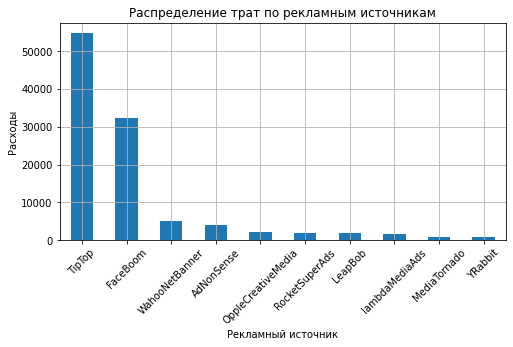

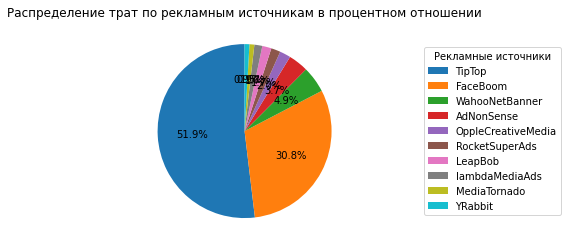

In [30]:
# визуализируем распределение трат по рекламным источникам
expenses['costs'].plot(kind = 'bar', grid = True, figsize=(8, 4))
plt.xlabel('Рекламный источник')
plt.ylabel('Расходы')
plt.title('Распределение трат по рекламным источникам')
plt.xticks(rotation=45)
plt.show()

# визуализируем распределение трат по рекламным источникам в процентном отношении
expenses['costs'].plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(4, 4), labels=['']*len(expenses))
plt.legend(expenses.index, title="Рекламные источники", loc="center left", bbox_to_anchor=(1.3, 0, 0.5, 1))
plt.title('Распределение трат по рекламным источникам в процентном отношении')
plt.ylabel('')
plt.title('Распределение трат по рекламным источникам в процентном отношении')
plt.ylabel('')
plt.show()

Всего было использовано 10 рекламных источников, расходы на которые составляют от 944.22 (рекламный источник YRabbit) до 54751.3 (рекламный источник TipTop).\
По сумме расходов значительно выделяются два источника: TipTop и FaceBoom (более 82% от общей суммы расходов на маркетинг).

#### Визуализация динамики изменения расходов во времени по неделям и по месяцам по каждому источнику

In [31]:
# смотрим данные
display(costs.head())
costs.info()

,dt,channel,costs
0,2019-05-01,FaceBoom,113.3
1,2019-05-02,FaceBoom,78.1
2,2019-05-03,FaceBoom,85.8
3,2019-05-04,FaceBoom,136.4
4,2019-05-05,FaceBoom,122.1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       1800 non-null   object 
 1   channel  1800 non-null   object 
 2   costs    1800 non-null   float64
dtypes: float64(1), object(2)
memory usage: 42.3+ KB


In [32]:
# переводим в формат datetime64, потому что формат datetime.date, в который мы переводили
# ранее, не работает с методами .dt.isocalendar().week и .dt.month
costs['dt'] = pd.to_datetime(costs['dt'])

costs['week'] = costs['dt'].dt.isocalendar().week
costs['month'] = costs['dt'].dt.month
display(costs)

,dt,channel,costs,week,month
0,2019-05-01,FaceBoom,113.3,18,5
1,2019-05-02,FaceBoom,78.1,18,5
2,2019-05-03,FaceBoom,85.8,18,5
3,2019-05-04,FaceBoom,136.4,18,5
4,2019-05-05,FaceBoom,122.1,18,5
...,...,...,...,...,...
1795,2019-10-23,lambdaMediaAds,4.0,43,10
1796,2019-10-24,lambdaMediaAds,6.4,43,10
1797,2019-10-25,lambdaMediaAds,8.8,43,10
1798,2019-10-26,lambdaMediaAds,8.8,43,10


,channel,week,costs
0,AdNonSense,18,211.05
1,AdNonSense,19,273.00
2,AdNonSense,20,265.65
3,AdNonSense,21,266.70
4,AdNonSense,22,202.65
...,...,...,...
255,lambdaMediaAds,39,80.00
256,lambdaMediaAds,40,59.20
257,lambdaMediaAds,41,60.80
258,lambdaMediaAds,42,47.20


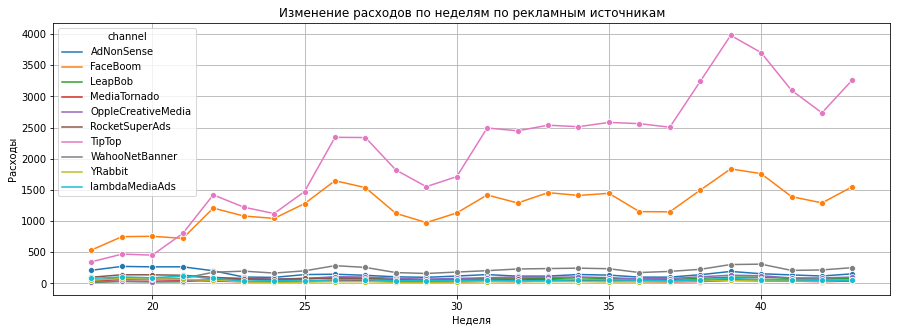

In [33]:
# считаем расходы по неделям по каждому рекламному источнику
expenses_week = costs.groupby(['channel', 'week']).agg({'costs':'sum'}).reset_index()
display(expenses_week)

# строим линейный график динамики изменения расходов по неделям по рекламным источникам
plt.figure(figsize=(15, 5))
sns.lineplot(data=expenses_week, x='week', y='costs', hue='channel',  marker='o')
plt.grid(True) 
plt.xlabel('Неделя')
plt.ylabel('Расходы')
plt.title('Изменение расходов по неделям по рекламным источникам')
plt.show()

,channel,month,costs
0,AdNonSense,5,1169.70
1,AdNonSense,6,538.65
2,AdNonSense,7,504.00
3,AdNonSense,8,579.60
4,AdNonSense,9,581.70


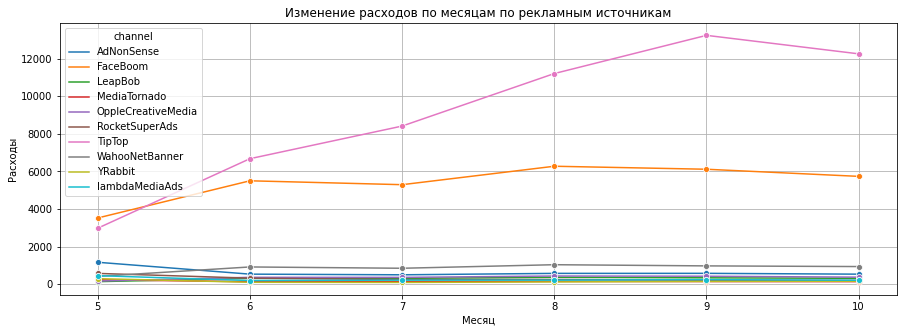

In [34]:
# считаем расходы по месяцам по каждому рекламному источнику
expenses_month = costs.groupby(['channel', 'month']).agg({'costs':'sum'}).reset_index()
display(expenses_month.head())

# строим линейный график динамики изменения расходов по месяцам по рекламным источникам
plt.figure(figsize=(15, 5))
sns.lineplot(data=expenses_month, x='month', y='costs', hue='channel', marker='o')
plt.grid(True) 
plt.xlabel('Месяц')
plt.ylabel('Расходы')
plt.title('Изменение расходов по месяцам по рекламным источникам')
plt.show()

Каналы TipTop и FaceBoom заметно выделяются по тратам.

Во времени по неделям траты на такие рекламные источники, как FaceBoom и TipTop, росли, но с некоторыми проседаниями (22-23 недели, 26-28 недели и 39-41) и пиками (22, 26, 31 и 39 недели).\
Траты на источник AdNonSense уменьшились с 21 недели, а на WahooNetBanner наоборот после 21 недели выросли.

Во времени по месяцам траты на такие рекламные источники, как FaceBoom и TipTop, росли, кроме трат 10го месяца на источник TipTop и трат 7го, 9го и 10го месяцев на источник FaceBoom.\
Траты на источник AdNonSense уменьшились к 6му месяцу, а на источник WahooNetBanner наоборот к 6му месяцу выросли.\
В динамике изменений трат по неделям и месяцам на другие рекламные источники выделяющихся изменений не наблюдается.

#### Расчет средней стоимости привлечения одного пользователя (CAC) из каждого источника

In [35]:
# убираем органику
profiles_paid_traf = profiles.query("channel != 'organic'")

# рассчитываем среднюю стоимость привлечения пользователя (САС) по всем источникам за все время
avg_cac = profiles_paid_traf['acquisition_cost'].mean().round(4)
print(f'Средняя стоимость привлечения пользователя по всем источникам за все время: {avg_cac}')

Средняя стоимость привлечения пользователя по всем источникам за все время: 1.1275


In [36]:
# рассчитываем среднюю стоимость привлечения пользователя (САС) по каждому источнику за все время
avg_cac_channel = profiles.groupby('channel').agg({'acquisition_cost':'mean'}).round(4)\
.sort_values(by='acquisition_cost', ascending=False)
avg_cac_channel.columns = ['avg_cac']
display(avg_cac_channel)

,avg_cac
channel,
TipTop,2.7990
FaceBoom,1.1133
AdNonSense,1.0081
lambdaMediaAds,0.7248
WahooNetBanner,0.6022
RocketSuperAds,0.4121
OppleCreativeMedia,0.2500
YRabbit,0.2190
MediaTornado,0.2187


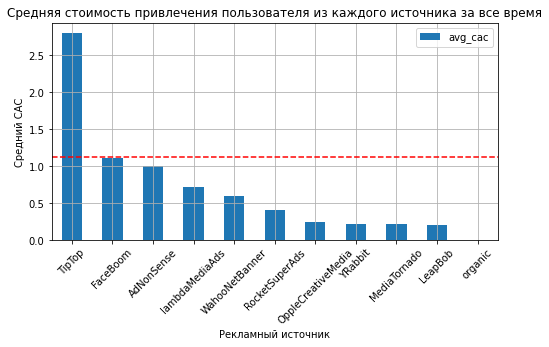

In [37]:
# визуализируем средний САС по каждому источнику за все время
avg_cac_channel.plot(kind = 'bar', grid = True, figsize=(8, 4))
# добавляем горизонтальную линию средний CAC по всем источникам для сравнения
plt.axhline(y=avg_cac, color='red', linestyle='--')
plt.xlabel('Рекламный источник')
plt.ylabel('Средний САС')
plt.title('Средняя стоимость привлечения пользователя из каждого источника за все время')
plt.xticks(rotation=45)
plt.show()

In [38]:
# рассчитываем среднюю стоимость привлечения пользователя (САС) по всем источникам в динамике по месяцам
avg_cac_month = profiles.groupby(['month']).agg({'acquisition_cost':'mean'}).round(4).reset_index()
avg_cac_month.columns = ['month','avg_cac']
avg_cac_month['month'] = avg_cac_month['month'].dt.month
display(avg_cac_month)

,month,avg_cac
0,5,0.3681
1,6,0.6526
2,7,0.7269
3,8,0.7770
4,9,0.8524
5,10,0.8617


In [39]:
# рассчитываем среднюю стоимость привлечения пользователя (САС) по каждому источнику в динамике по месяцам
avg_cac_channel_month = profiles_paid_traf.groupby(['channel', 'month']).agg({'acquisition_cost':'mean'}).round(4)\
.reset_index()
avg_cac_channel_month.columns = ['channel', 'month','avg_cac']
avg_cac_channel_month['month'] = avg_cac_channel_month['month'].dt.month
display(avg_cac_channel_month.head())

,channel,month,avg_cac
0,AdNonSense,5,1.0279
1,AdNonSense,6,1.0125
2,AdNonSense,7,0.9921
3,AdNonSense,8,0.9959
4,AdNonSense,9,1.0047


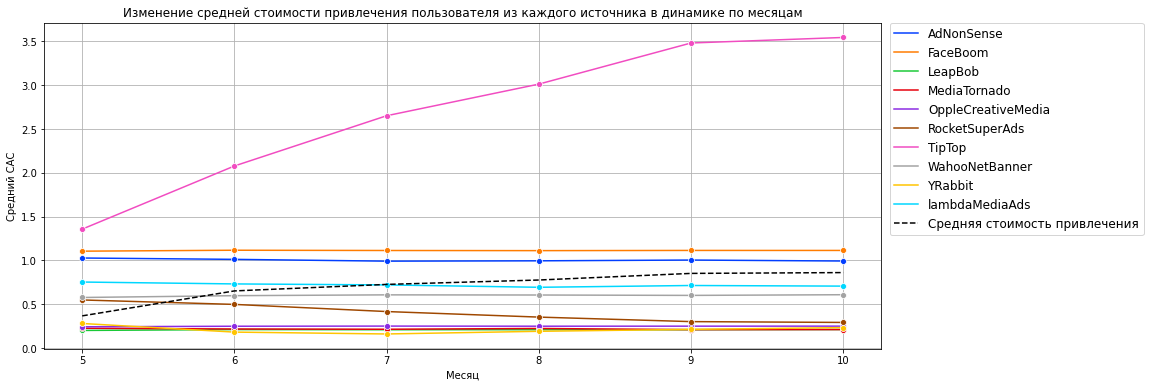

In [40]:
# строим линейный график динамики изменения среднего САС из каждого источника по месяцам
plt.figure(figsize=(15, 6))
sns.lineplot(data=avg_cac_channel_month, x='month', y='avg_cac', hue='channel', palette='bright', marker='o')
# линия для сравнения
plt.plot(avg_cac_month['month'], avg_cac_month['avg_cac'], label='Средняя стоимость привлечения', linestyle='--', color='black')
plt.grid(True) 
plt.xlabel('Месяц')
plt.ylabel('Средний САС')
plt.title('Изменение средней стоимости привлечения пользователя из каждого источника в динамике по месяцам')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0., prop={'size': 12})
plt.show()

Средняя стоимость привлечения пользователя (средний САС) за весь период исследования была наибольшей из источника TipTop (2.7990)(более чем в 2 раза больше, чем из других источников), а наименьшей из источника LeapBob (0.2102).\
Средний САС из остальных источников колеблется в пределах от 0.2187 до 1.1133.\
Источник organic же имеет нулевую стоимость привлечения клиента.

В динамике по месяцам средняя стоимость привлечения пользователя менялась следующим образом:
1) средний САС из источника TipTop значительно и стабильно рос, так, что к концу исследуемого периода вырос примерно в 2.5 раза;\
2) средний САС из источника RocketSuperAds постепенно слегка снизился;\
3) средний САС из других источников не менялся или менялся незначительно.

####  Выводы по анализу маркетинга 

1. Общая сумма расходов на маркетинг составила 105497.3.


2. Всего было использовано 10 рекламных источников, расходы на которые составляют от 944.22 (рекламный источник YRabbit) до 54751.3 (рекламный источник TipTop). При этом по сумме расходов значительно выделяются два источника: TipTop и FaceBoom (более 82% от общей суммы расходов на маркетинг).


3. а) Во времени по неделям траты на такие рекламные источники, как FaceBoom и TipTop, росли, но с некоторыми проседаниями (22-23 недели, 26-28 недели и 39-41) и пиками (22, 26, 31 и 39 недели). Траты на источник AdNonSense уменьшились с 21 недели, а на WahooNetBanner наоборот после 21 недели выросли.\
б) Во времени по месяцам траты на такие рекламные источники, как FaceBoom и TipTop, росли, кроме трат 10го месяца на источник TipTop и трат 7го, 9го и 10го месяцев на источник FaceBoom. Траты на источник AdNonSense уменьшились к 6му месяцу, а на источник WahooNetBanner наоборот к 6му месяцу выросли.\
в) В динамике изменений трат по неделям и месяцам на другие рекламные источники выделяющихся изменений не наблюдается.


4. Средняя стоимость привлечения пользователя по всем источникам за все время равняется 1.1275.\
а) Средняя стоимость привлечения пользователя (средний САС) за весь период исследования была наибольшей из источника TipTop (2.7990), а наименьшей из источника LeapBob (0.2102). Средний САС из остальных источников колеблется в пределах от 0.2187 до 1.1133.Источник organic же имеет нулевую стоимость привлечения клиента.\
б) В динамике по месяцам средний САС из источника TipTop значительно и стабильно рос, так, что к концу исследуемого периода выросла примерно в 2.5 раза; средний САС из источника RocketSuperAds постепенно слегка снизился; средний САС из других источников не менялся или менялся незначительно.


### Оценка окупаемости рекламы

Используя графики LTV, ROI и CAC, проанализируйте окупаемость рекламы. Считайте, что на календаре 1 ноября 2019 года, а в бизнес-плане заложено, что пользователи должны окупаться не позднее чем через две недели после привлечения. Необходимость включения в анализ органических пользователей определите самостоятельно.

- Проанализируйте окупаемость рекламы c помощью графиков LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Проверьте конверсию пользователей и динамику её изменения. То же самое сделайте с удержанием пользователей. Постройте и изучите графики конверсии и удержания.
- Проанализируйте окупаемость рекламы с разбивкой по устройствам. Постройте графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Проанализируйте окупаемость рекламы с разбивкой по странам. Постройте графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Проанализируйте окупаемость рекламы с разбивкой по рекламным каналам. Постройте графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Ответьте на такие вопросы:
    - Окупается ли реклама, направленная на привлечение пользователей в целом?
    - Какие устройства, страны и рекламные каналы могут оказывать негативное влияние на окупаемость рекламы?
    - Чем могут быть вызваны проблемы окупаемости?

Напишите вывод, опишите возможные причины обнаруженных проблем и промежуточные рекомендации для рекламного отдела.

In [41]:
# отфильтруем профили, убрав "органических пользователей", так как рекламы
# и соответственно трат на нее на их привлечение не было 
profiles_paid_traf = profiles.query("channel != 'organic'")

In [42]:
# зададим момент и горизонт анализа
observation_date = datetime(2019, 11, 1).date() # момент анализа
horizon_days = 14 # горизонт анализа 

#### Анализ окупаемости рекламы c помощью графиков LTV и ROI, а также анализ графиков динамики LTV, CAC и ROI

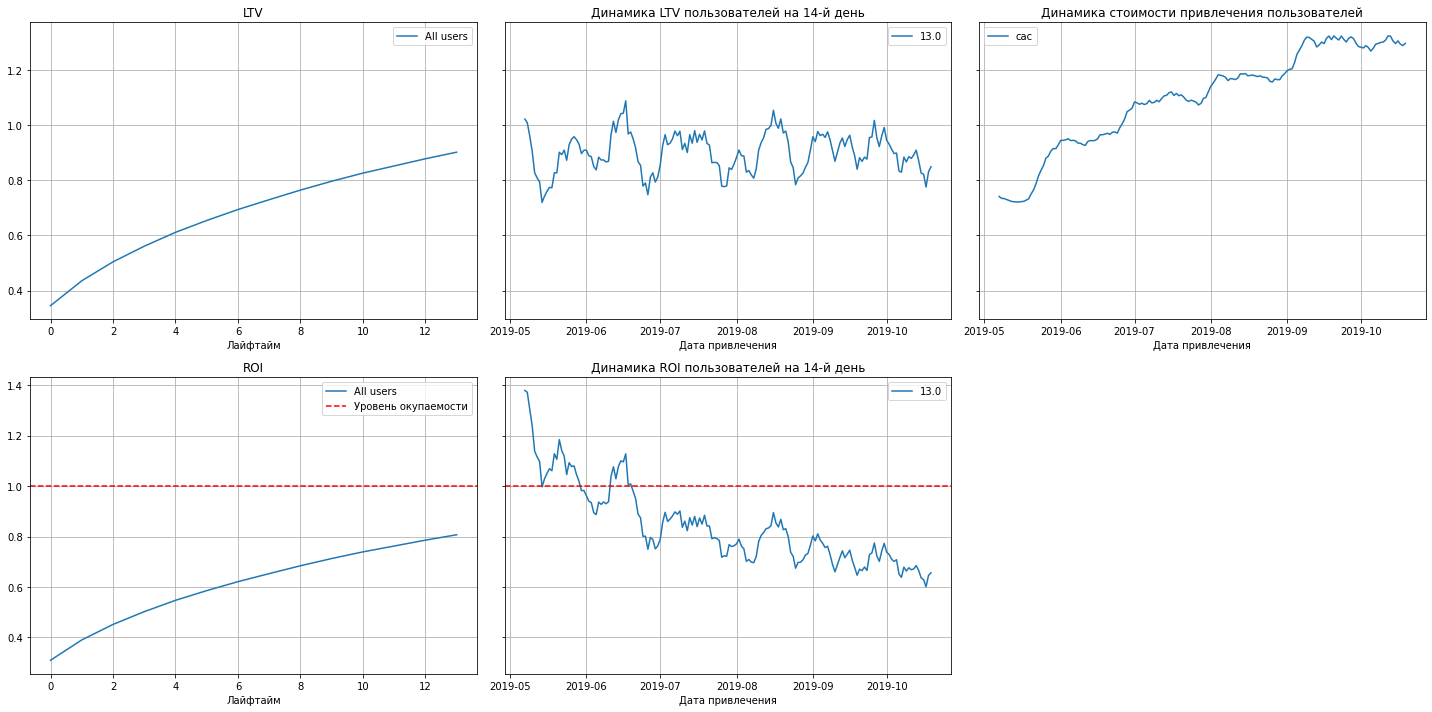

In [43]:
# расчитываем LTV и ROI в отношении пользователей из платных источников
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_paid_traf, orders, observation_date, horizon_days, dimensions=[]
)

# строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

1. LTV растет с каждым днем лайфтайма пользователя.
2. Реклама не окупается, к 13 дню лайфтайма ROI чуть выше 80%.
3. На LTV в некоторой степени влияет внутримесячная сезонность, но этот параметр достаточно стабилен.
4. CAC постоянно растет с мая по октябрь.
5. ROI снижается с мая по октябрь, и затраты на рекламу окупались только в мае и июне, а далее компания уходила в минус.

#### Конверсия пользователей и динамика её изменения. Удержание пользователей и динамика её изменения.

##### Конверсия пользователей Conversion Rate и динамика её изменения

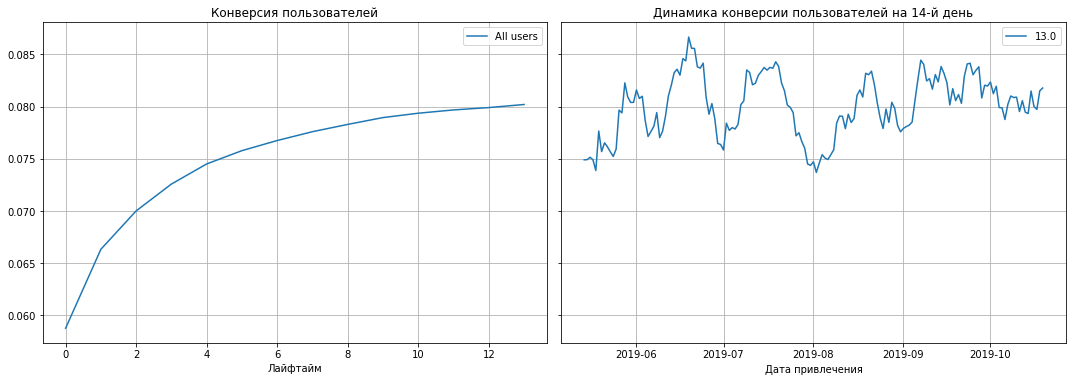

In [44]:
# расчитываем конверсию пользователей из платных источников
conversion_raw, conversion, conversion_history = get_conversion(
    profiles_paid_traf, orders, observation_date, horizon_days, dimensions=[])

plot_conversion(conversion, conversion_history, horizon_days, window=14) 

Конверсия пользователей, пришедших из рекламных источников, постепенно растет в течение всего лайфтайма, к концу периода достигая примерно 8%, причем до 4 дня лайфтайма она увеличивается более активными темпами (на 4й день лайфтайма она составляет 7.5%), чем с 5го.\

Выражена внутримесячная сезонность в период с июня по август: пики, наблюдаемые в середине июня, июля и августа, доходя примерно до 8.4-8.6%, сменялись спадами в конце месяца (до 7.6-7.7%) и ростом в начале следующего.\
Уровень конверсии в мае был самым низким за рассматриваемый период (около 7.5%). В октябре же конверсия установилась примерно на среднем уровне (8%) по сравнению с другими месяцами.

##### Удержание пользователей Retention Rate и динамика его изменения

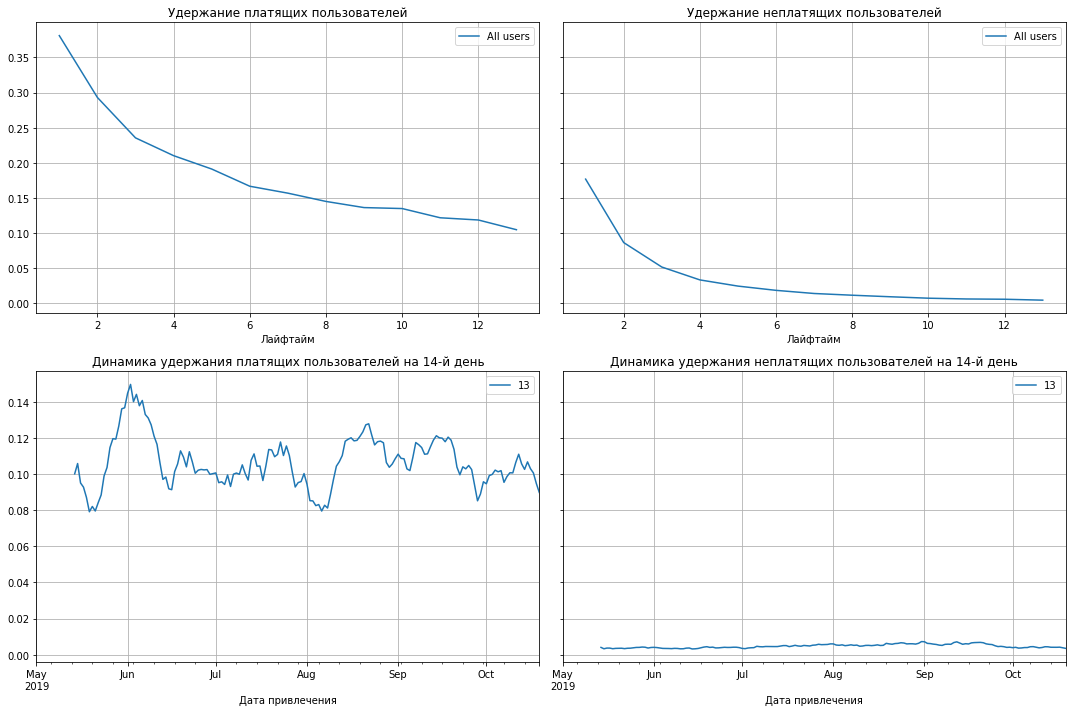

In [45]:
# расчитываем удержание пользователей из платных источников
retention_raw, retention, retention_history = get_retention(
    profiles_paid_traf, visits, observation_date, horizon_days, dimensions=[]
)

plot_retention(retention, retention_history, horizon_days, window=14)

Неплатящие пользователи практически не возвращаются в приложение: на второй день лайфтайма приложением продолжают пользоваться лишь 8% пользователей, а далее их количество снижается и стремится к нулю.\
В разрезе по месяцам удержание неплатящих пользователей на 14-й день составляет около 1%, хотя и незначительно выше в августе-сентябре.

Уровень удержания платящих пользователей значительно выше: на второй день лайфтайма приложением продолжают пользоваться 30% пользователей, а на 13-й день — 10%.\
Наблюдается некоторая сезонность в уровне удержания платящих пользователей на 14-й день: ярко выраженный пик (15%) приходится на конец мая и начало июня. В середине июля, августа и сентября удержание находится на уровне около 11-13%, в то время как в мае, начале августа и конце сентября уровень удержания снижается до 8%.

#### Анализ окупаемости рекламы с разбивкой по устройствам помощью графиков LTV и ROI, а также анализ графиков динамики LTV, CAC и ROI

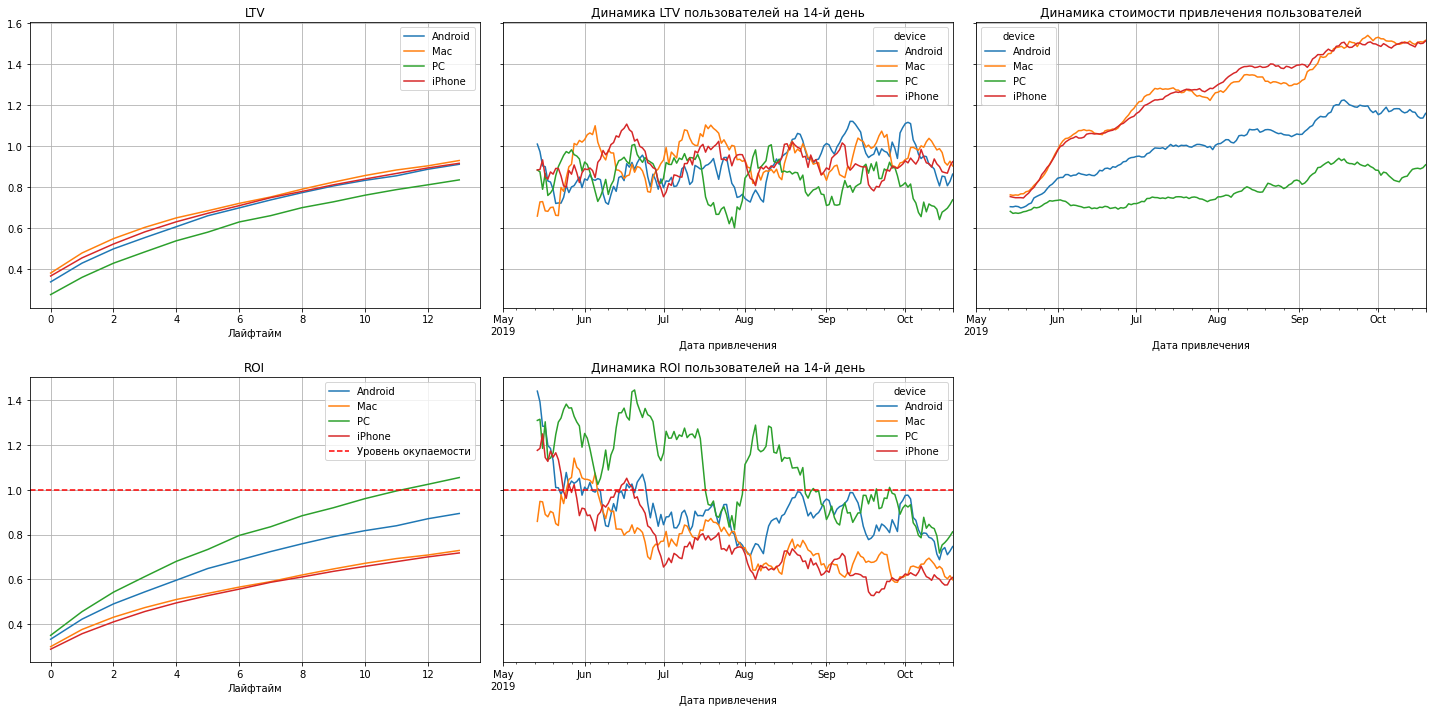

In [46]:
# смотрим окупаемость пользователей из платных источников с разбивкой по устройствам

dimensions = ['device']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_paid_traf, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
) 

LTV на всех устройствах стабильно растет в течение первых 14 дней лайфтайма, однако показатели на PC немного отстают. При этом наблюдается сезонность в динамике LTV на разных устройствах в разное время.

Стоимость привлечения пользователей с разными устройствами также стабильно растет с мая по октябрь. При этом начальные уровни стоимости примерно одинаковы для всех устройств, но на iPhone и Mac она растет намного быстрее, чем на других платформах. Самый плавный рост стоимости наблюдается у привлечения пользователей PC.

Реклама окупается только для пользователей PC начиная с 11 дня лайфтайма в период с мая по конец августа, за исключением снижения во второй половине июля. Для пользователей Android и iPhone реклама была выгодна только до середины мая и в середине июня, а для пользователей Mac она окупалась только в конце мая и начале июня.

#### Анализ окупаемости рекламы с разбивкой по странам с помощью графиков LTV и ROI, а также анализ графиков динамики LTV, CAC и ROI

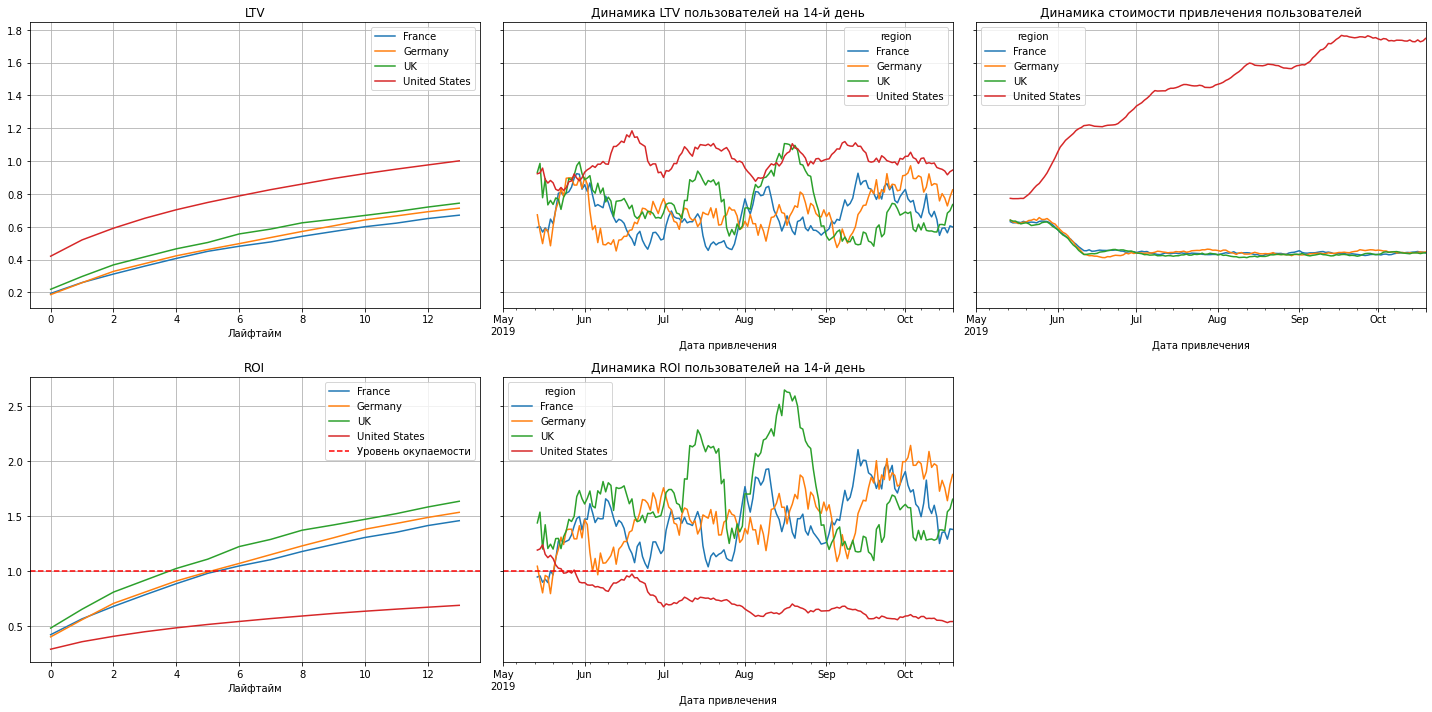

In [47]:
# смотрим окупаемость пользователей из платных источников с разбивкой по странам

dimensions = ['region']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_paid_traf, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
) 

LTV пользователей из США выше LTV пользователей других стран как в течение всего периода рассматриваемого лайфтайма, так и в динамике с мая по октябрь.

При этом из-за того, что стоимость привлечения пользователей из США в несколько раз выше стоимости привлечения пользователей из других стран (которые после небольшого снижения держатся на одном, довольно невысоком, уровне), ROI выходит на положительный уровень с 4-6 дня лайфтайма у всех стран, кроме США.\
В динамике окупаемости рекламы с середины мая по октябрь США также является явным аутсайдером. А вот реклама для привлечения пользователей из Франции, Германии и Великобритании окупается практически в течение всего рассматриваемого периода.

#### Анализ окупаемости рекламы с разбивкой по рекламным каналам с помощью графиков LTV и ROI, а также анализ графиков динамики LTV, CAC и ROI

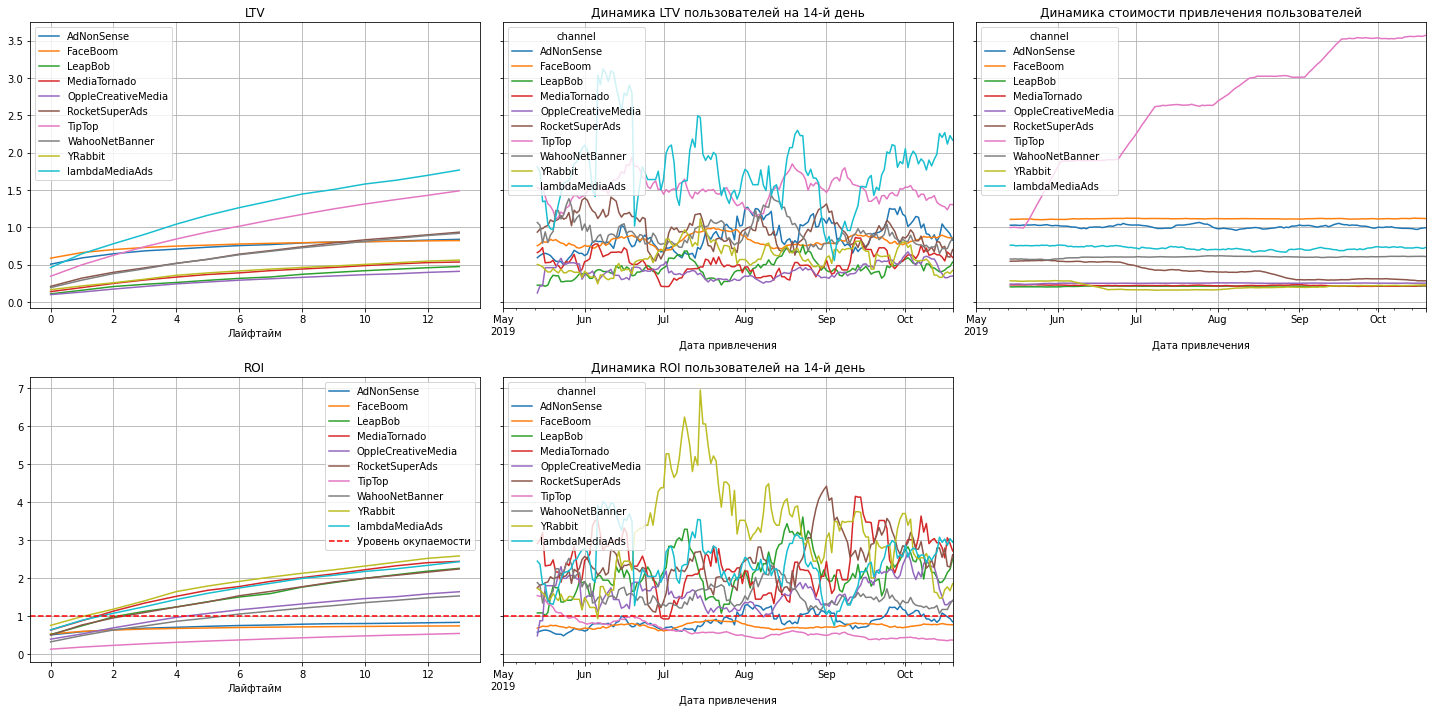

In [48]:
# смотрим окупаемость пользователей из платных источников с разбивкой по рекламным каналам
dimensions = ['channel']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_paid_traf, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
   ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
) 

LTV стабилен, хотя подвержен сезонности.

Стоимость привлечения пользователей из разных рекламных источников относительно стабильна, кроме источника TipTop (у него она постоянно и довольно сильно растет).

Затраты не окупаются на привлечение пользователей из источников, на которые больше всего уходит средств из бюджета: TipTop, FaceBoom и сезонно AdNonSense.

#### Промежуточный вывод

1. Показатели конверсии и удержания пользователей, привлеченных через рекламные источники, в целом демонстрируют удовлетворительные результаты.
2. В общем у всех пользователей, привлеченных из платных источников, LTV удовлетворителен и стабилен, но реклама не окупается как в расчете на лайфтаймы пользователей (к 13 дню лайфтайма ROI чуть выше 80%), так и в динамике - с середины июня компания уходит в минус.
3. Благодаря не такой высокой как у других платформ стоимости привлечения пользователей с устройствами PC, реклама, направленная на эту категорию окупалась, но нестабильно и только с мая по конец августа. Реклама для привлечения пользователей с другими устройствами из-за более высокой стоимости окупалась же только в мае и середине июня, до повышения CAC.
4. Реклама на привлечение пользователей из США не окупалась с середины мая из-за очень дорогой стоимости привлечения. Однако реклама, направленная на привлечение пользователей из Франции, Германии и Великобритании, окупалась в течение всего рассматриваемого периода, за небольшим исключением в мае, к тому же пользователи из этих стран начинали окупаться уже с 4-6 дней лайфтайма.
5. Реклама в источниках TipTop, FaceBoom и AdNonSense себя не окупала, в случае канала TipTop это объясняется высокой стоимостью привлечения пользователей.

В связи с обнаруженными проблемами с окупаемостью рекламы для привлечения пользователей с устройствами PC и пользователей из США, а также с рекламой через источники TipTop, FaceBoom и AdNonSense проведем исследование конверсии и удержания по странам, устройствам и источникам.

#### Дополнительное исследование конверсии и удержания по странам, устройствам и рекламным источникам

##### По странам

###### Конверсия пользователей и динамика её изменения по странам

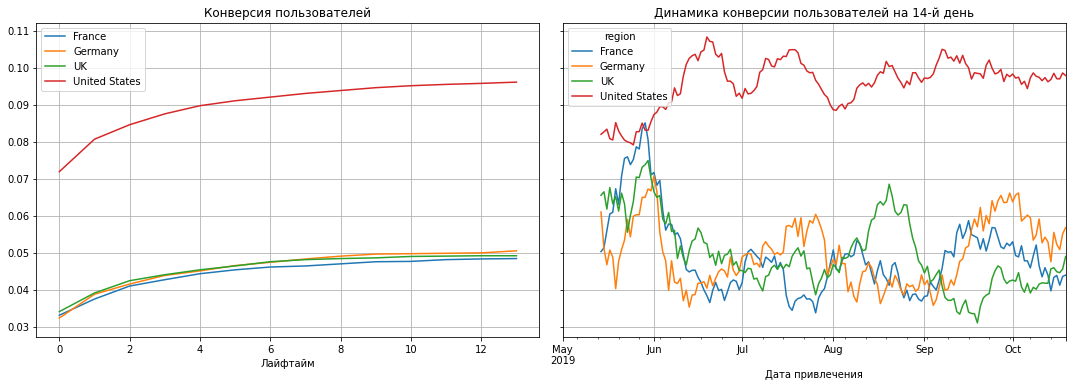

In [49]:
# расчитываем конверсию пользователей по странам из платных источников
conversion_raw, conversion, conversion_history = get_conversion(
    profiles_paid_traf, orders, observation_date, horizon_days, dimensions=['region'])

plot_conversion(conversion, conversion_history, horizon_days, window=14) 

Пользователи из США конвертируются значительно лучше пользователей из других стран, конверсия которых же находится примерно на одном уровне.

###### Удержание пользователей и динамика его изменения по странам

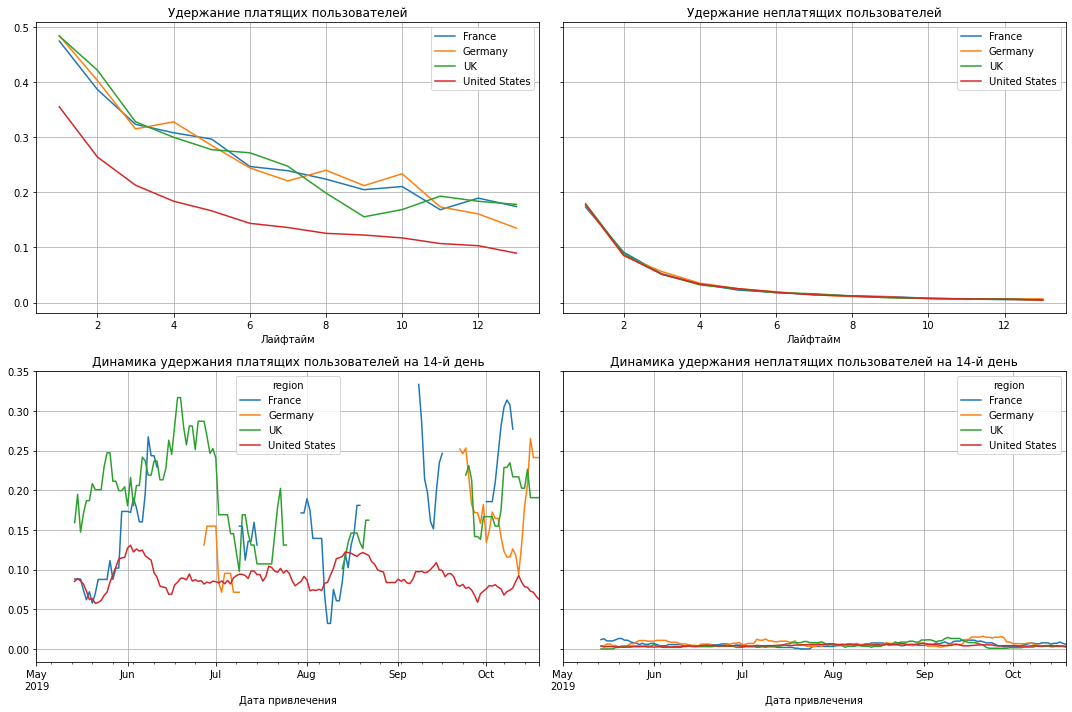

In [50]:
# расчитываем удержание пользователей из платных источников
retention_raw, retention, retention_history = get_retention(
    profiles_paid_traf, visits, observation_date, horizon_days, dimensions=['region']
)

plot_retention(retention, retention_history, horizon_days, window=14)

Пользователи из США удерживаются в приложении хуже, чем пользователи из других стран.

##### По устройствам

###### Конверсия пользователей и динамика её изменения по устройствам

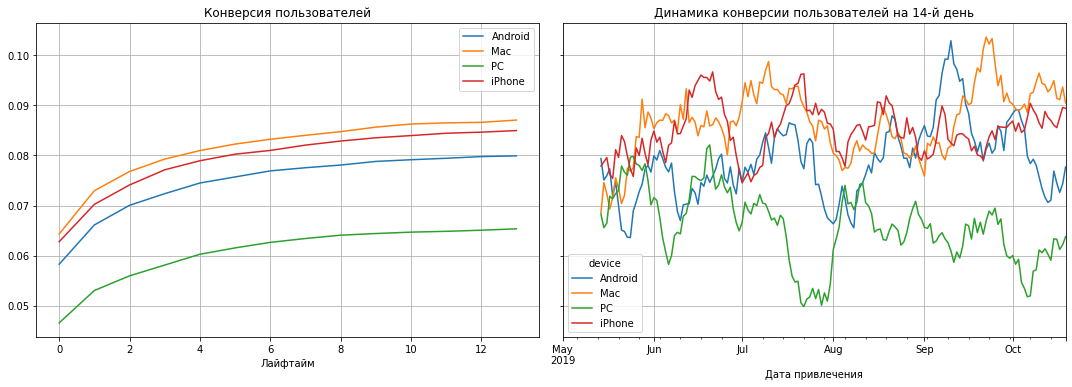

In [51]:
# расчитываем конверсию пользователей по странам из платных источников
conversion_raw, conversion, conversion_history = get_conversion(
    profiles_paid_traf, orders, observation_date, horizon_days, dimensions=['device'])

plot_conversion(conversion, conversion_history, horizon_days, window=14) 

Пользователи с устройствами PC конвертируются хуже пользователей с другими устройствами.

###### Удержание пользователей и динамика его изменения по устройствам

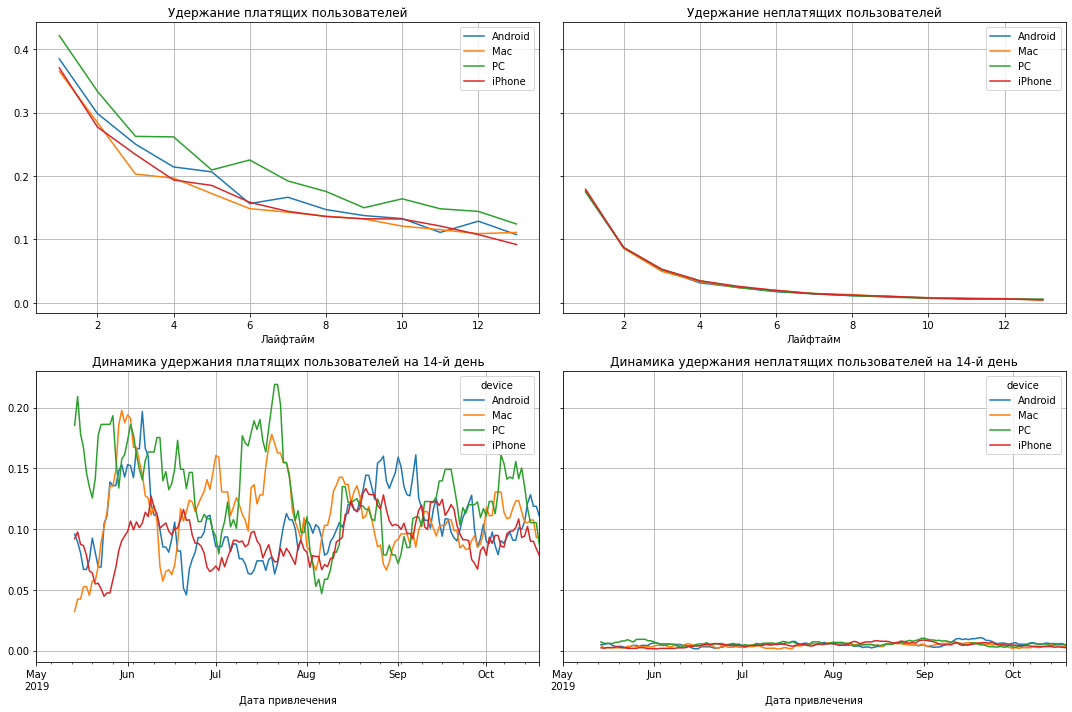

In [52]:
# расчитываем удержание пользователей из платных источников
retention_raw, retention, retention_history = get_retention(
    profiles_paid_traf, visits, observation_date, horizon_days, dimensions=['device']
)

plot_retention(retention, retention_history, horizon_days, window=14)

Удержание пользователей с разными устройствами примерно одинаково.

##### По рекламным каналам

###### Конверсия пользователей и динамика её изменения по рекламным каналам

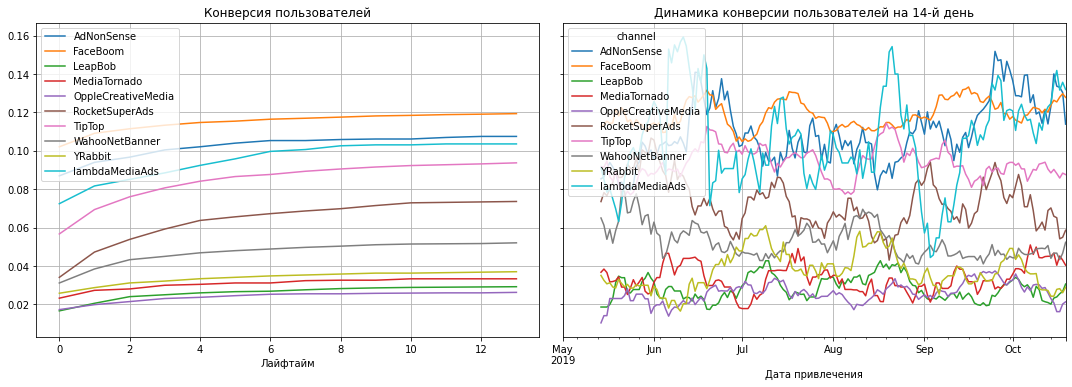

In [53]:
# расчитываем конверсию пользователей по рекламным каналам из платных источников
conversion_raw, conversion, conversion_history = get_conversion(
    profiles_paid_traf, orders, observation_date, horizon_days, dimensions=['channel'])

plot_conversion(conversion, conversion_history, horizon_days, window=14)  

Уровни конверсии пользователей из каналов FaceBoom, AdNonSense, lambdaMediaAds и TipTop выше уровней конверсии пользователей из других источников.\
Уровни конверсии пользователей из каналов OppleCreativeMedia и LeapBob ниже уровней конверсии пользователей из других источников.

###### Удержание пользователей и динамика его изменения по рекламным источникам

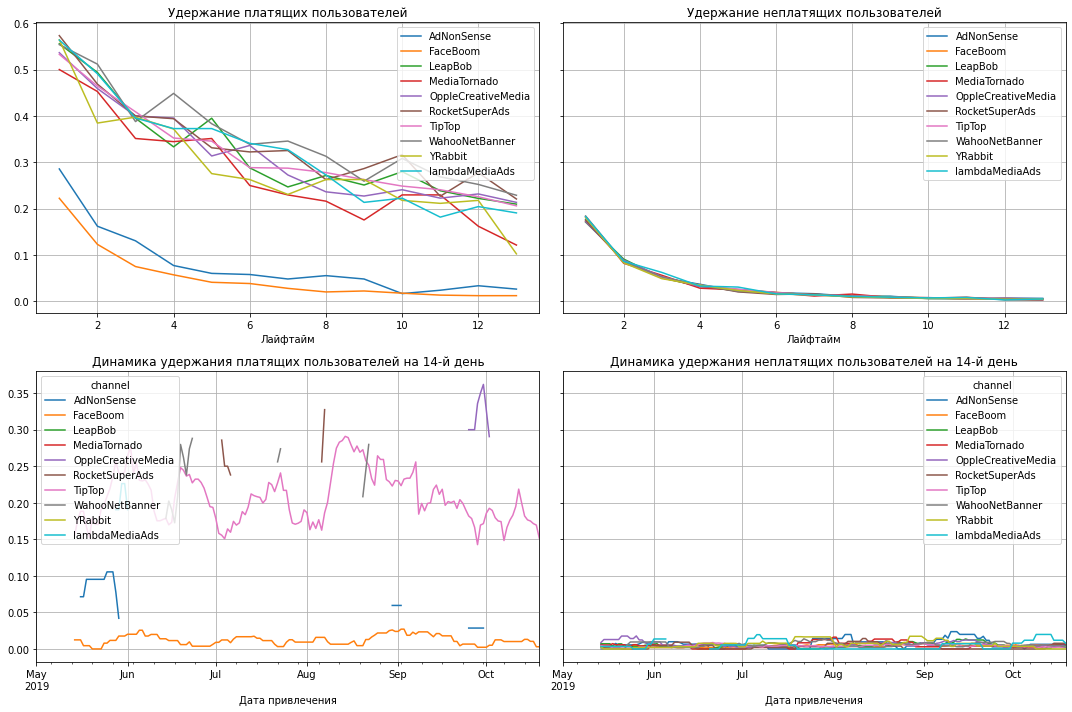

In [54]:
# расчитываем удержание пользователей из платных источников
retention_raw, retention, retention_history = get_retention(
    profiles_paid_traf, visits, observation_date, horizon_days, dimensions=['channel']
)

plot_retention(retention, retention_history, horizon_days, window=14)

Платящие пользователи из каналов FaceBoom и AdNonSense удерживаются намного хуже пользователей из других рекламных источников.

#### Выводы и причины неокупаемости рекламы

В ходе исследования проблемы с окупаемостью рекламы было выяснено следующее:
1. Реклама для привлечения пользователей из США не окупается из-за более низкого уровня удержания и более высокого уровня стоимости привлечения по сравнению с этими же показателями других стран.


2. Реклама для привлечения пользователей с устройствами Android, Mac и iPhone не окупается из-за более высокой стоимости привлечения пользователей, чем пользователей с PC, на фоне стабильных LTV и удержания. Но при этом из-за снижающегося уровня конверсии пользователей с PC реклама на их привлечение также перестает окупаться с сентября.


3. Реклама на привлечение пользователей из канала TipTop не окупается из-за высокой стоимости привлечения, которая еще и регулярно растет, на фоне стабильного LTV.\
А реклама через каналы FaceBoom и AdNonSense не окупается из-за очень низкого уровня удержания платящих пользователей на фоне стабильного LTV и CAC.

#### Ответы на вопросы

##### Окупается ли реклама, направленная на привлечение пользователей в целом?

Начиная с конца июня реклама совсем не окупается.

##### Какие устройства, страны и рекламные каналы могут оказывать негативное влияние на окупаемость рекламы?

К таким устройствам можно отнести Android, Mac и iPhone, с сентября еще и PC.\
Странам: США.\
Рекламным каналам: TipTop, FaceBoom и AdNonSense.

##### Чем могут быть вызваны проблемы окупаемости?

Реклама в США - низкий уровень удержания и высокий уровень стоимости привлечения.\
Канал TipTop - высокая стоимость привлечения, которая еще и регулярно растет, на фоне стабильного LTV.\
Каналы FaceBoom и AdNonSense - низкий уровень удержания платящих пользователей при стабильном LTV и CAC.\
Устройства Android, Mac и iPhone - высокая стоимость привлечения на фоне стабильных LTV и удержания.\
Устройство PC - снижающийся уровень конверсии при стабильном LTV.

#### Промежуточные рекомендации:

1. Возможно, стоит пересмотреть подход к работе с рекламными источниками TipTop, FaceBoom и AdNonSense или приостановить рекламу через них.
2. К тому же, вероятно, пересмотрев методы и каналы привлечения пользователей из США, получится снизить стоимость привлечения пользователей из этой страны, тем самым увеличить окупаемость рекламы.

#### Дополнительное исследование по альтернативным регионам

##### Окупаемость рекламы в Европе

In [55]:
# уберем США из датафрейма
profile_europe = profiles_paid_traf.query("region != 'United States'")
print(profile_europe['region'].unique())

['Germany' 'France' 'UK']


###### По устройствам

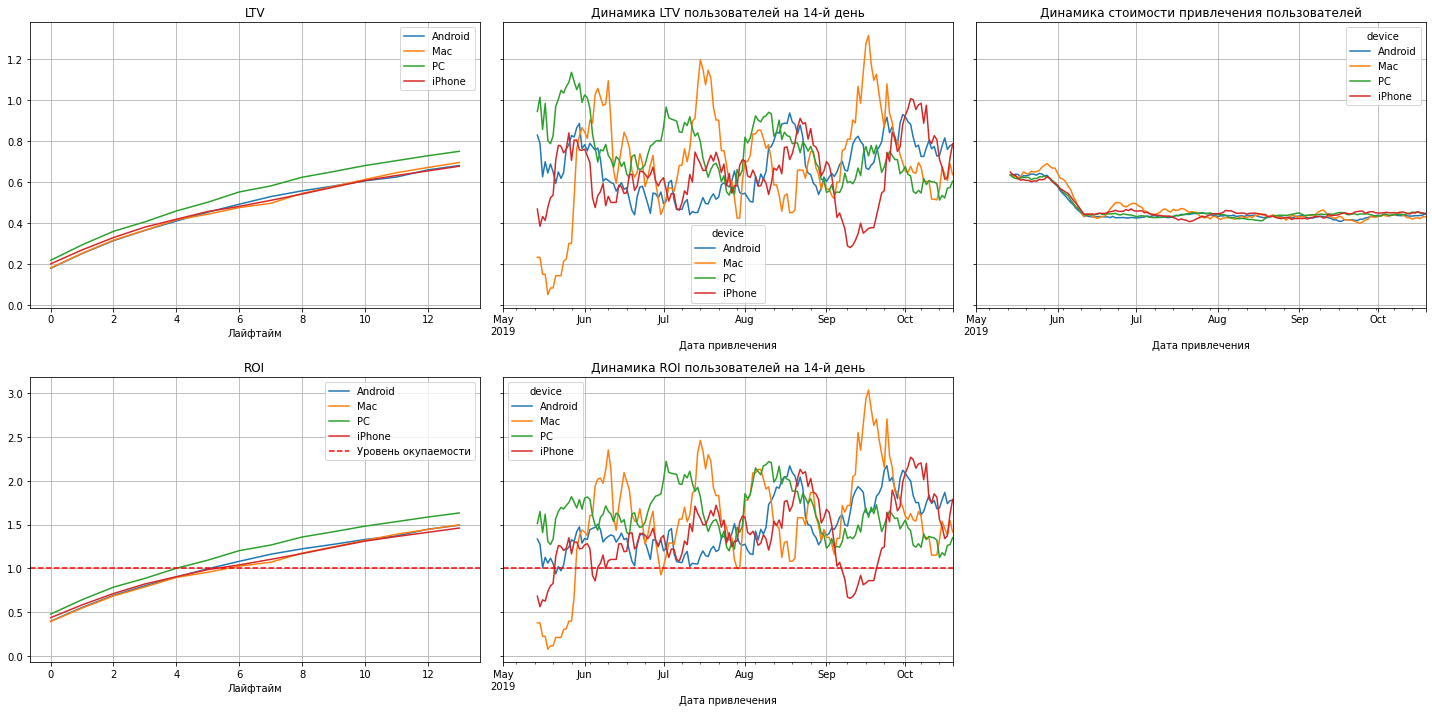

In [56]:
# смотрим окупаемость пользователей из Европы из платных источников с разбивкой по устройствам

dimensions = ['device']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profile_europe, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
) 

###### По рекламным источникам

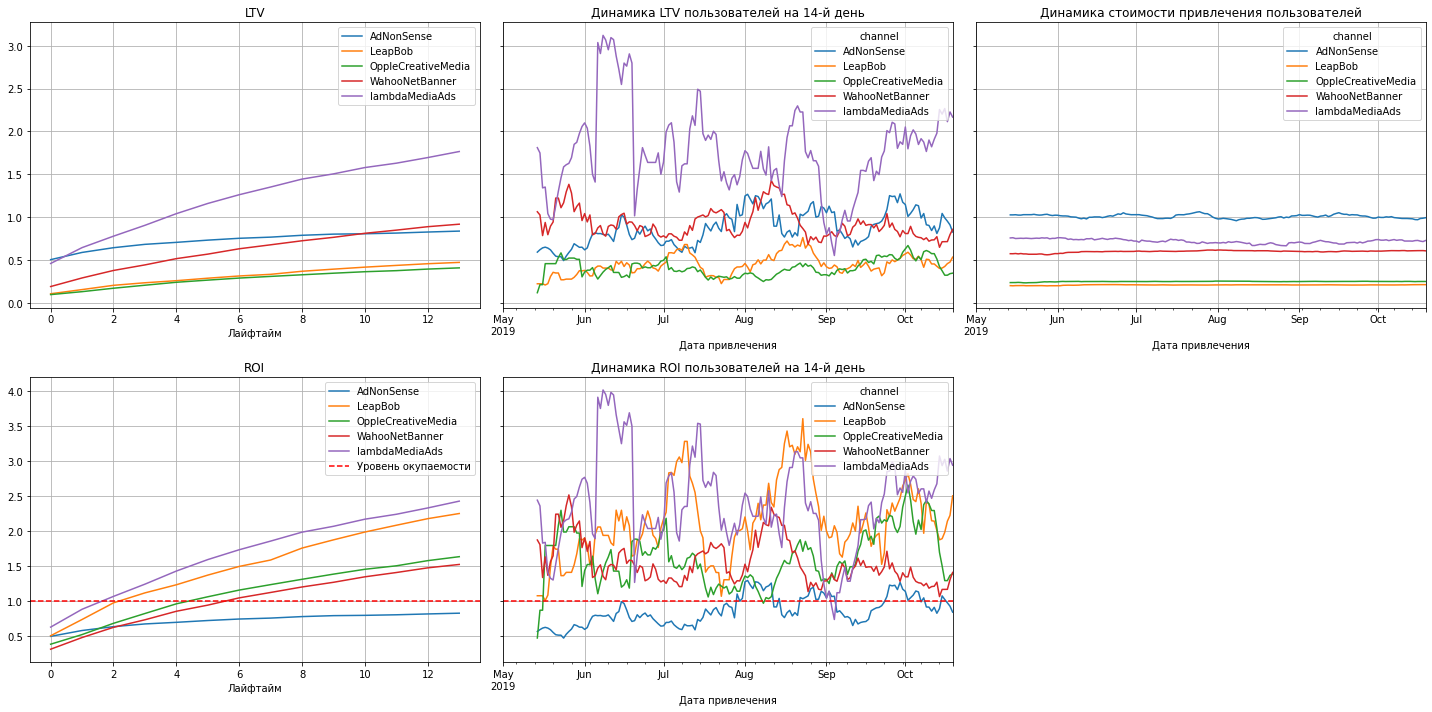

In [57]:
# смотрим окупаемость пользователей из Европы из платных источников с разбивкой по каналам

dimensions = ['channel']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profile_europe, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
) 

**Вывод:**
1. Реклама в Европе для всех устройств окупается с 4-6 дня.
2. Реклама в Европе окупается для всех рекламных источников, за исключением AdNonSense - из-за низкого уровня удержания (было выяснено ранее).

##### Окупаемость рекламы в США

In [58]:
# оставим только США
profile_usa = profiles_paid_traf.query("region == 'United States'")
print(profile_usa['region'].unique())

['United States']


###### По устройствам

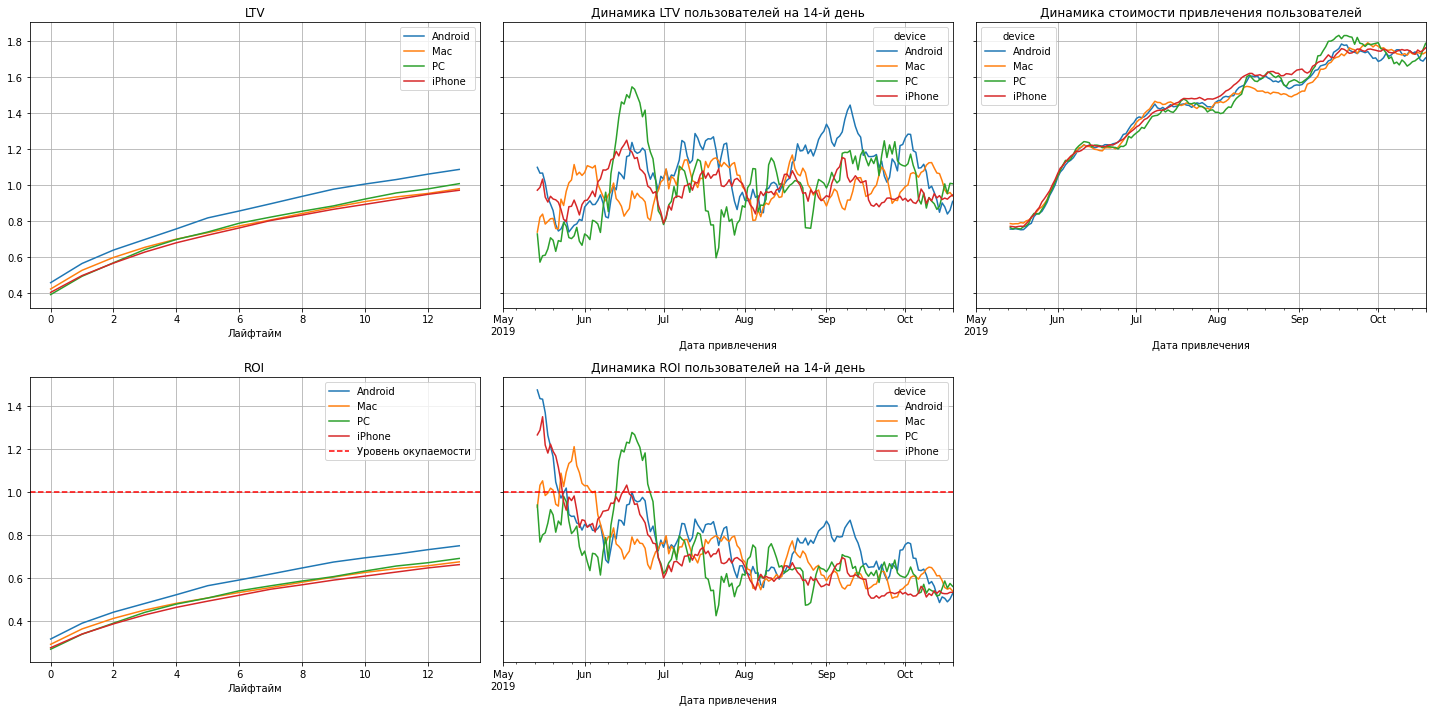

In [59]:
# смотрим окупаемость пользователей из США из платных источников с разбивкой по устройствам

dimensions = ['device']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profile_usa, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
) 

###### По рекламным источникам

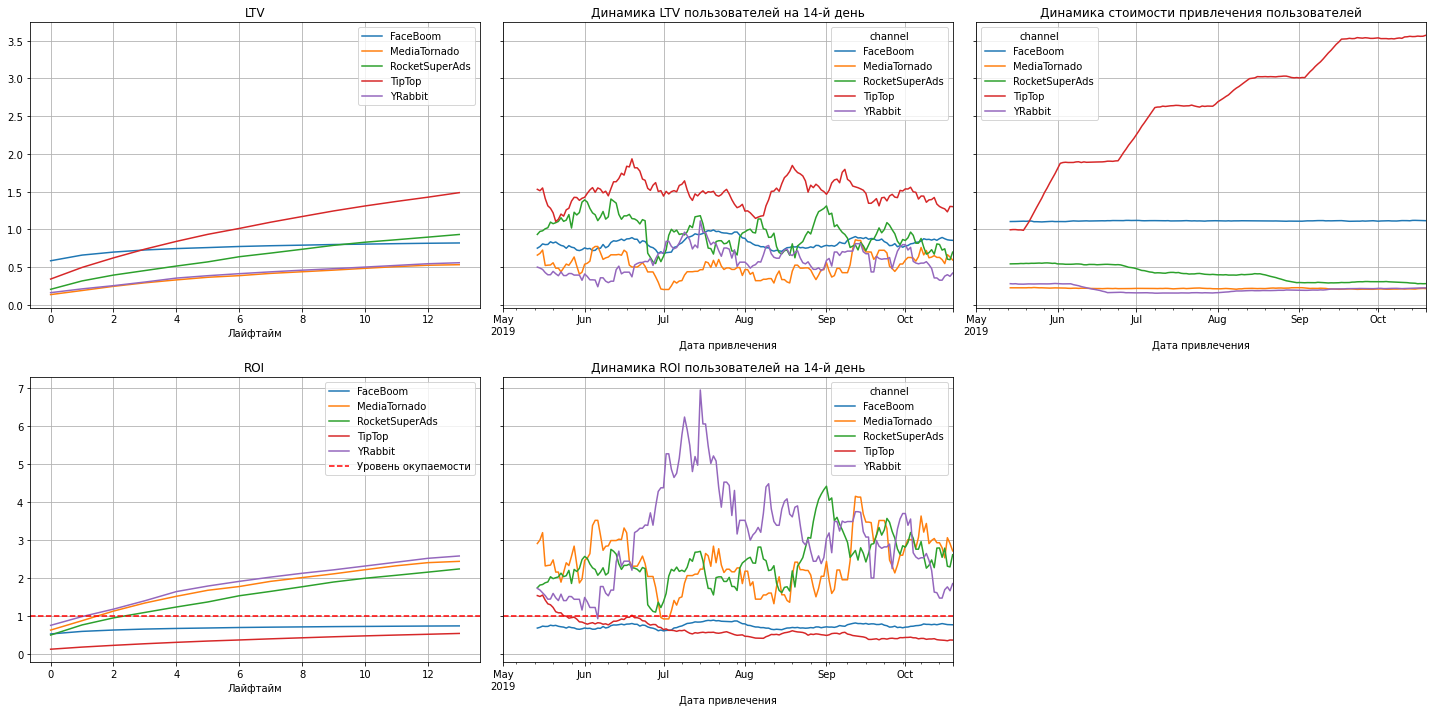

In [60]:
# смотрим окупаемость пользователей из США из платных источников с разбивкой по каналам

dimensions = ['channel']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profile_usa, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
) 

**Без источников, которые не окупаются**

In [61]:
profile_usa2 = profile_usa.query("channel not in ['TipTop', 'FaceBoom']") 

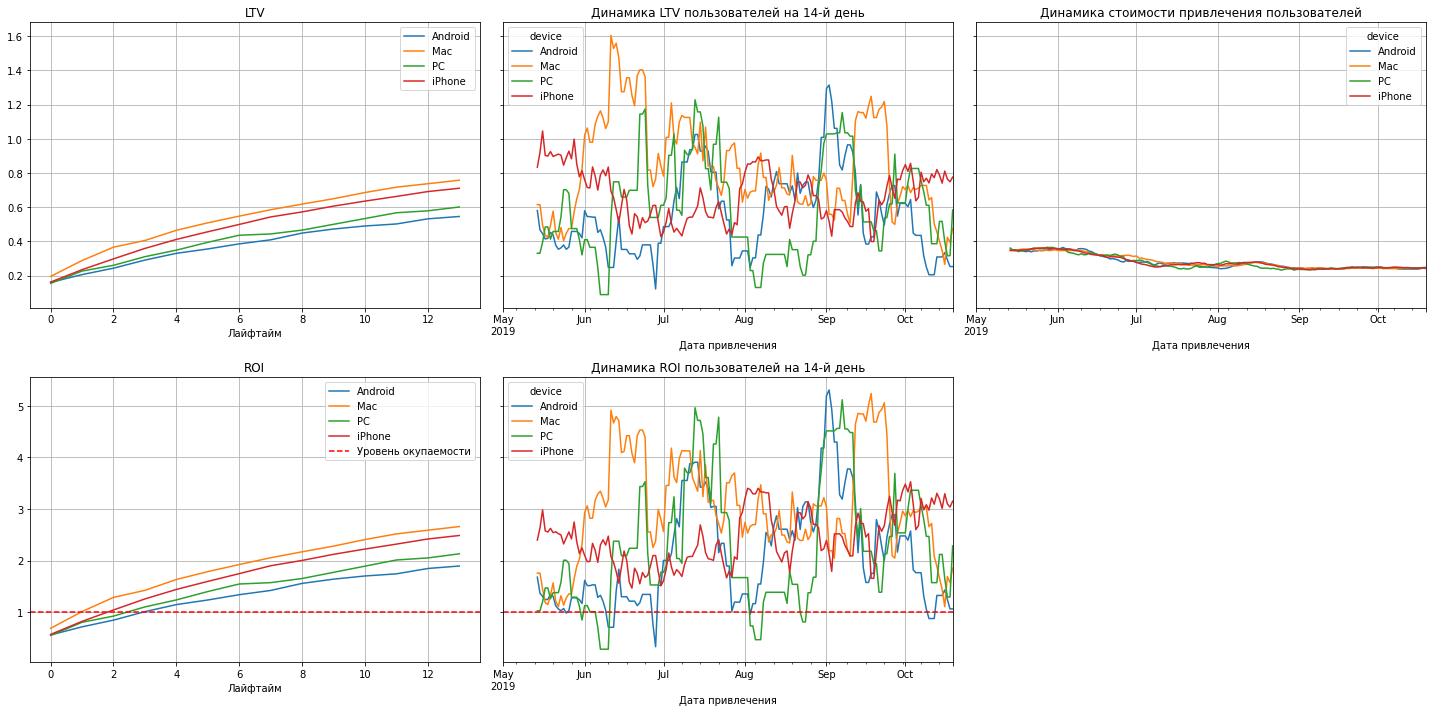

In [62]:
dimensions = ['device']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profile_usa2, orders, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
) 

**Вывод:**
1. Реклама в США не окупается для канала TipTop из-за постоянно растущей стоимости привлечения, а для канала FaceBoom - из-за низкого уровня удержания (было выяснено ранее).
2. Реклама в США окупается для всех устройств с 1-3 дня лайфтайма, если исключить рекламу через неокупающиеся каналы - TipTop и FaceBoom.
 

### Итоговые выводы

- Выделите причины неэффективности привлечения пользователей.
- Сформулируйте рекомендации для отдела маркетинга.

**Исследование проводилось на основе** данных о пользователях развлекательного приложения Procrastinate Pro+, привлечённых с 1 мая по 27 октября 2019 года, содержащихся в трех датафреймах (посещения, покупки и рекламные расходы).
<br>
<br>

**Задача была следующая:**
Проанализировать данные, разобраться по какой причине компания терпит убытки и сформулировать рекомендации для отдела маркетинга.
<br>
<br>

**На этапе предобработки:**
1. Не было выявлено пропусков и явных/неявных дубликатов.
2. Для ряда полей были изменены типы данных: 
- стороки на время и дату (для полей с датами); 
- из числовых значений в строки (для ID пользователей);
3. Все названия столбцов были изменены в соответствии с общепринятым стилем.
<br>
<br>

Были заданы функции для создания профилей пользователей, подсчета конверсии и удержания и расчета значений метрик LTV, ROI, CAC.
<br>
<br>

**На этапе исследовательского анализа данных было выявлено следующее:**
1. Минимальная и максимальная даты привлечения - 2019.05.01 и 2019.10.27 соответственно.


2. Пользователи приходят в приложение из США, Великобритании, Франции и Германии, больше всего - из США(100002 пользователей).Также именно на США приходятся наибольшие количество(6902) и доля(6.9%) платящих пользователей.\
Меньше всего пользователей из Германии (14981), количество платящих - 616 пользователей, доля - 4.1%.


3. Клиенты пользуются следующими устройствами: iPhone, Android, ПК, Mac, при этом наибольшее количество платящих(3382 пользователей) и всех пользователей(54479) используют iPhone. Но в долевом соотношении платящие пользователи предпочитают устройства iPhone(6.2%) и Mac (6.36%).\
Меньше всего пользователей приходят из устройств PC (30455), количество платящих - 1537 пользователей, доля - 5%.


4. Больше всего платящих и всех пользователей пришло из каналов: FaceBoom (29144), TipTop(19561) и organic (органический трафик)(56439). При этом доля платящих пользователей выше у каналов: FaceBoom(12.2%), AdNonSense(11.3%), lambdaMediaAds (10.47%).\
Меньше всего пользователей приходят из источника MediaTornado (4364), количество платящих - 156 пользователей, доля - 3.5%.
<br>
<br>

**На этапе анализа маркетинга было выявлено следующее:**
1. Общая сумма расходов на маркетинг составила 105497.3.


2. Всего было использовано 10 рекламных источников, расходы на которые составляют от 944.22 (рекламный источник YRabbit) до 54751.3 (рекламный источник TipTop). При этом по сумме расходов значительно выделяются два источника: TipTop и FaceBoom (более 82% от общей суммы расходов на маркетинг).


3. а) Во времени по неделям траты на такие рекламные источники, как FaceBoom и TipTop, росли, хоть и с некоторыми проседаниями (22-23 недели, 26-28 недели и 39-41) и пиками (22, 26, 31 и 39 недели). Траты на источник AdNonSense уменьшились с 21 недели, а на WahooNetBanner наоборот после 21 недели выросли.\
б) Во времени по месяцам траты на такие рекламные источники, как FaceBoom и TipTop, росли, кроме трат 10го месяца на источник TipTop и трат 7го, 9го и 10го месяцев на источник FaceBoom. Траты на источник AdNonSense уменьшились к 6му месяцу, а на источник WahooNetBanner наоборот к 6му месяцу выросли.\
в) В динамике изменений трат по неделям и месяцам на другие рекламные источники выделяющихся изменений не наблюдается.


4. Средняя стоимость привлечения пользователя по всем источникам за все время равняется 1.1275.\
а) Средняя стоимость привлечения пользователя (CAC) за весь период исследования была наибольшей из источника TipTop (2.7990), а наименьшей из источника LeapBob (0.2102). Средняя стоимость привлечения пользователя из остальных источников колеблется в пределах от 0.2187 до 1.1133. Источник organic же имеет нулевую стоимость привлечения клиента.\
б) В динамике по месяцам средняя стоимость привлечения пользователя из источника TipTop значительно и стабильно росла, так, что к концу исследуемого периода выросла примерно в 2.5 раза; средняя стоимость привлечения из источника RocketSuperAds постепенно слегка снизилась; а средняя стоимость привлечения пользователей из других источников не менялась или менялась незначительно.
<br>
<br>

**На этапе оценки окупаемости рекламы было выявлено следующее:**
1. Показатели конверсии и удержания пользователей, привлеченных через рекламные источники, демонстрируют удовлетворительные результаты.


2. В целом у всех пользователей, привлеченных из платных источников, LTV удовлетворителен и стабилен, но реклама не окупается как в расчете на лайфтаймы пользователей (к 13 дню лайфтайма ROI чуть выше 80%), так и в динамике - с середины июня компания уходит в минус.


3. Причины неокупаемости рекламы: \
1) Реклама для привлечения пользователей из США не окупается из-за более низкого уровня удержания и более высокого уровня стоимости привлечения по сравнению с этими же показателями других стран.\
2) Реклама для привлечения пользователей с устройствами Android, Mac и iPhone не окупается из-за более высокой стоимости привлечения пользователей, чем пользователей с PC, на фоне стабильных LTV и удержания. Но при этом из-за снижающегося уровня конверсии пользователей с PC реклама на их привлечение также перестает окупаться с сентября.\
3) Реклама на привлечение пользователей из канала TipTop не окупается из-за высокой стоимости привлечения, которая еще и регулярно растет, на фоне стабильного LTV. А реклама через каналы FaceBoom и AdNonSense не окупается из-за очень низкого уровня удержания платящих пользователей на фоне стабильного LTV и CAC.



**Возможные причины неэффективности привлечения пользователей:**
1. Высокая конкуренция среди подобных приложений.
2. Не учтены предпочтения и мнения пользователей разных регионов.
3. Недостатки в оптимизации приложения для разных платформ, в том числе платформы PC.
4. Проблемы локализации приложения.
<br>
<br>

**Возможные рекомендации для отдела маркетинга:**

*Для стран Европы:*
1. Стоит отказаться от рекламы приложения через рекламный канал AdNonSense. Низкий уровень удержания платящих пользователей приводит к тому, что реклама через этот канал не окупается.
2. Рекламу можно продолжать для всех типов устройств, поскольку она окупается на 4-6 день лайфтайма пользователей.
3. Наиболее перспективным каналом привлечения является lambdaMediaAds. Этот канал демонстрирует высокую эффективность, так как затраты на привлечение окупаются уже на 2й день лайфтайма пользователя. К тому же динамика LTV и ROI на четырнадцатый день также наиболее высокая у этого канала по сравнению с другими. Исходя из вышеперечисленного, рекомендуется уделить особое внимание дальнейшему развитию и оптимизации работы с lambdaMediaAds, чтобы максимально использовать его потенциал.

*Для США:*
1. Предлагается остановить рекламу через рекламные каналы TipTop и FaceBoom. Первый не окупается из-за высокой и постоянно растущей стоимости привлечения пользователей, а второй - из-за низкого уровня удержания.
2. Рекламу для всех типов устройств можно продолжать, она окупается с 1-3 дня лайфтайма, если исключить рекламу через TipTop и FaceBoom.
3. Наиболее перспективен канал YRabbit. У него неплохой показатель динамики LTV и отличный показатель динамики ROI, к тому же стоимость привлечения пользователей из него одна из самых низких (0.2190).